## 통계 검정 및 상관관계 분석

In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
df = pd.read_csv("data/first_clean_data.csv", index_col=0)

숙소 유형별 차이가 유의미한가?<br>
1. 가설설정<br>
귀무가설 : 숙소 유형별로 평균 가격은 같다.<br>
대립가설 : 숙소 유형별로 평균 가격이 다르다.

In [4]:
df.groupby("room_type")["price"].count().sort_values(ascending=False)

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: price, dtype: int64

In [5]:
df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_type
Hotel room         537.600000
Entire home/apt    265.557657
Shared room        169.728571
Private room       130.826869
Name: price, dtype: float64

<Axes: title={'center': 'price'}, xlabel='room_type'>

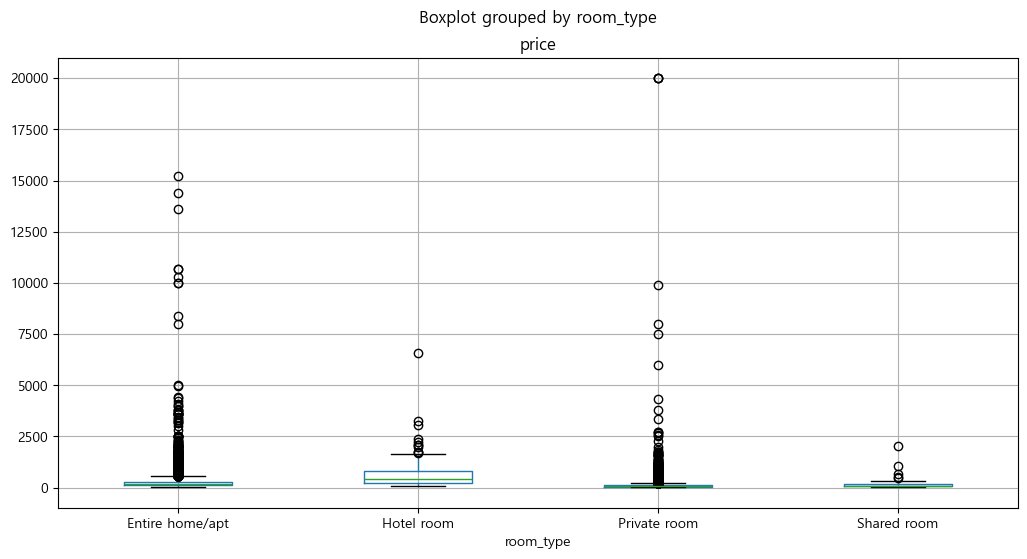

In [6]:
df.boxplot(column="price", by="room_type")

<Axes: title={'center': 'log_price'}, xlabel='room_type'>

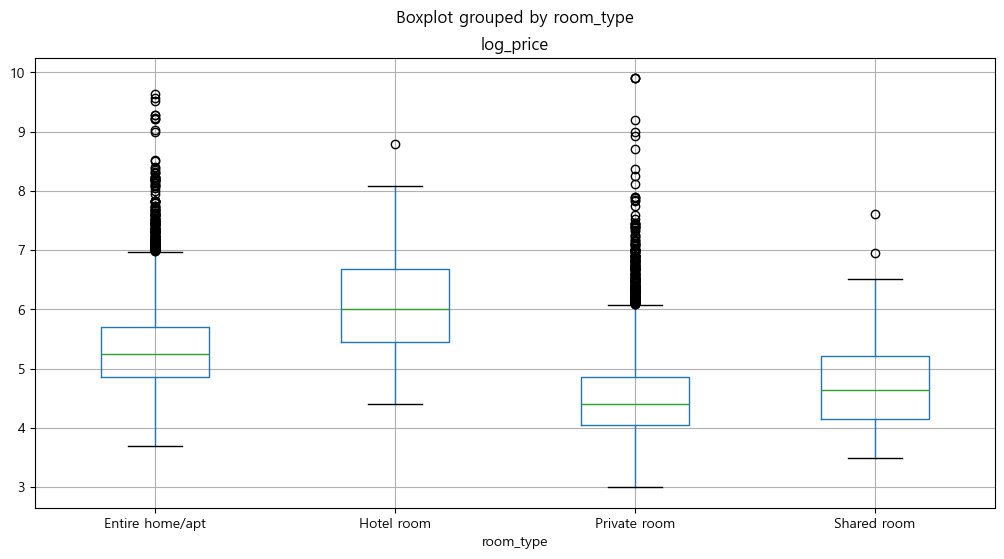

In [7]:
df.boxplot(column="log_price", by="room_type")

숙소 유형별 차이가 유의미한가?<br>
1. 가설설정<br>
귀무가설 : 숙소 유형별로 평균 가격은 같다.<br>
대립가설 : 숙소 유형별로 평균 가격이 다르다.

In [8]:
df['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

In [9]:
g1 = df.loc[df['room_type']=='Entire home/apt','price']
g2 = df.loc[df['room_type']=='Private room','price']
g3 = df.loc[df['room_type']=='Hotel room','price']
g4 = df.loc[df['room_type']=='Shared room','price']

2. 검정방법 <선택> <br>
후보1: 일원 ANOVA<br>
조건에 맞는지 1)정규성 2)등분산성 3)독립성

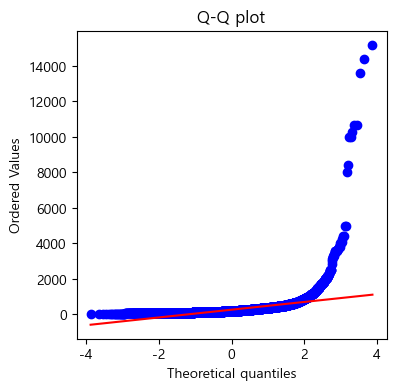

In [10]:
plt.figure(figsize=(4,4))
stats.probplot(g1, plot=plt)
plt.title("Q-Q plot")
plt.show()

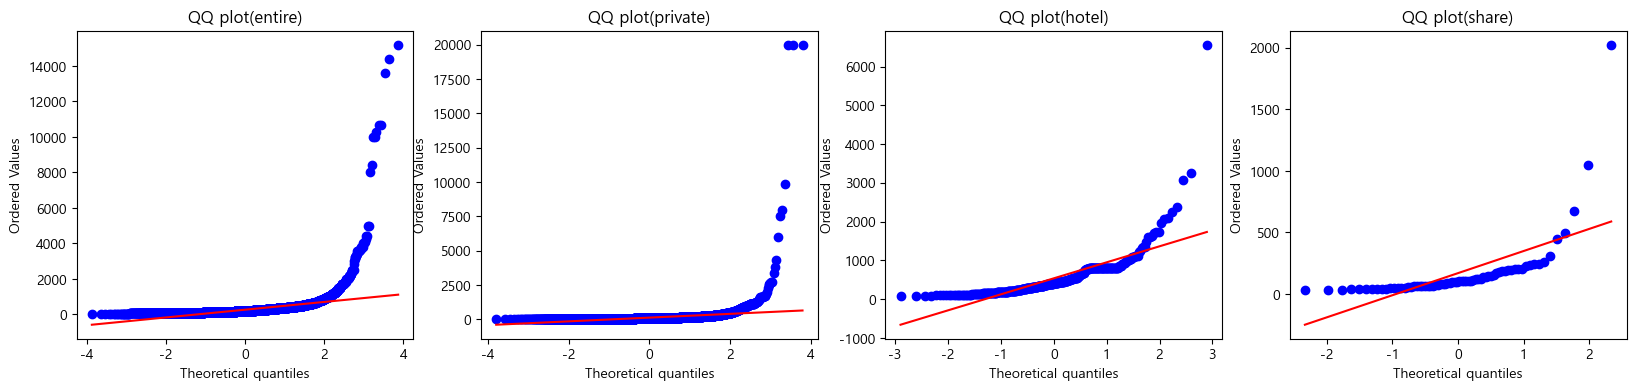

In [11]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(g1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(g2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(g3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(g4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

3. 유의수준 결정 : 0.05
4. 검정 통계량, p-value 계산

In [12]:
stat, p = stats.kruskal(g1, g2, g3, g4)
stat, p

(np.float64(7284.52185170291), np.float64(0.0))

5. 결과해석<br>
p-value가 유의수준보다 낮으므로 귀무가설 기각.(p < 0.05)<br>

귀무가설 : 숙소 유형별로 평균 가격은 같다.<br>
대립가설 : 숙소 유형별로 평균 가격이 다르다.<br>
사후검정 (Dunn test)

In [13]:
# Dunn 사후검정 
data = df[['room_type', 'price']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="price",
                        group_col="room_type",
                        p_adjust="holm"
                        )# Dunn 사후검정 
data = df[['room_type', 'price']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="price",
                        group_col="room_type",
                        p_adjust="holm"
                        )
posthoc

,Entire home/apt,Hotel room,Private room,Shared room
Entire home/apt,1.000000e+00,4.350104e-37,0.000000e+00,2.217586e-13
Hotel room,4.350104e-37,1.000000e+00,8.469899e-252,6.290908e-33
Private room,0.000000e+00,8.469899e-252,1.000000e+00,4.542803e-02
Shared room,2.217586e-13,6.290908e-33,4.542803e-02,1.000000e+00


카이제곱 독립성 검정<br>
룸 타입별 vs 지역

귀무가설 : 두 범주형 변수는 독립적이다.<Br>
대립가설 : 두 범주형 변수는 독립적이지 않다.

In [14]:
display(df['neighbourhood_group_cleansed'].isna().sum())
display(df['neighbourhood_group_cleansed'].value_counts(dropna=False))

np.int64(0)

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

In [15]:
ct = pd.crosstab(df['room_type'], df['neighbourhood_group_cleansed'])
result = chi2_contingency(ct)

result

Chi2ContingencyResult(statistic=np.float64(1646.3567796675218), pvalue=np.float64(0.0), dof=12, expected_freq=array([[5.17371674e+02, 4.22643249e+03, 5.77286835e+03, 1.93886597e+03,
        1.79461525e+02],
       [1.49458378e+01, 1.22093222e+02, 1.66766676e+02, 5.60099784e+01,
        5.18428623e+00],
       [3.75816163e+02, 3.07005915e+03, 4.19338233e+03, 1.40838242e+03,
        1.30359942e+02],
       [2.86632506e+00, 2.34151384e+01, 3.19826501e+01, 1.07416397e+01,
        9.94246674e-01]]))

p-value가 0에 가까우니까 두 범주형 변수는 관계가 있다.<br>
크래머 v계수 계산하기

In [16]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

In [17]:
cramers_v(ct)

np.float64(0.15705648117352444)

크래머V 계수가 0.1이상으로 약한 상관관계가 있다.

In [18]:
categorical_cols = [
    "host_response_time",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed"
]

In [19]:
ct1 = pd.crosstab(df['room_type'], df['host_response_time'])
ct2 = pd.crosstab(df['room_type'], df['host_is_superhost'])
ct3 = pd.crosstab(df['room_type'], df['neighbourhood_cleansed'])
ct4 = pd.crosstab(df['room_type'], df['neighbourhood_group_cleansed'])

print(cramers_v(ct1))
print(cramers_v(ct2))
print(cramers_v(ct3))
print(cramers_v(ct4))

0.08277075416451467
0.06156069544850748
0.2863052441361376
0.15705648117352444


In [20]:
for col in categorical_cols:
    drop = df[['room_type', col]].dropna()
    ct = pd.crosstab(drop['room_type'], drop[col])
    print(f"컬럼명 : {col}, 크래머v: {cramers_v(ct)}")

컬럼명 : host_response_time, 크래머v: 0.08277075416451467
컬럼명 : host_is_superhost, 크래머v: 0.06156069544850748
컬럼명 : neighbourhood_cleansed, 크래머v: 0.2863052441361376
컬럼명 : neighbourhood_group_cleansed, 크래머v: 0.15705648117352444


host_response_time => 0.08 매우약한 상관관계<br>
host_is_superhost => 0.06 매우약한 상관관계<br>
neighbourhood_cleansed => 0.28 약한 상관관계<br>
neighbourhood_group_cleansed => 0.15 매우약한 상관관계<Br>
범주 vs 수치형 상관관계 확인

In [21]:
# 2. 그 중 수치형 데이터만 추출
numeric_col = df.select_dtypes(include=['number']).columns.tolist()
numeric_col

['id',
 'host_id',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'log_price']

In [22]:
numeric_col.remove('id')
numeric_col.remove('host_id')
numeric_col.remove('host_response_time')

numeric_col

['host_response_rate',
 'host_acceptance_rate',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'log_price']

1. 가설설정 - ANOVA ->정규성불만족. Kruskal-Wallis 검정
Q. 각 방 유형별로 호스트 응답률이 다 비슷비슷한가요?

귀무가설 : 방 유형별로 호스트 응답률의 평균은 모두 같다.
대립가설 : 방 유형별로 호스트 응답률의 평균은 적어도 하나 이상 다르다.

In [23]:
display(df['host_response_rate'].isna().sum())
display(df['host_response_rate'].value_counts(dropna=False))

np.int64(0)

host_response_rate
 100.0    12858
-1.0       4389
 99.0       719
 98.0       549
 0.0        436
 90.0       349
 68.0       305
 80.0       215
 97.0       196
 92.0       182
 42.0       174
 50.0       173
 94.0       150
 91.0       129
 96.0       126
 95.0       103
 75.0        94
 67.0        90
 79.0        88
 93.0        80
 48.0        78
 89.0        68
 60.0        65
 83.0        63
 86.0        57
 88.0        53
 70.0        50
 82.0        35
 33.0        30
 87.0        28
 25.0        26
 78.0        24
 85.0        24
 40.0        22
 20.0        22
 81.0        21
 41.0        21
 30.0        20
 57.0        18
 71.0        15
 56.0        15
 10.0         8
 74.0         7
 38.0         7
 53.0         6
 65.0         6
 17.0         5
 34.0         5
 76.0         5
 36.0         5
 63.0         4
 46.0         4
 61.0         4
 77.0         3
 14.0         2
 44.0         2
 58.0         2
 29.0         2
 84.0         2
 72.0         2
 73.0         2
 16.0

In [24]:
# 호스트 응답률의 결측치를 -1로 전처리 해놔서 제외 필요함.
temp = df[['room_type', 'host_response_rate']].copy()
temp = temp[temp['host_response_rate'] != -1].dropna()

In [25]:
rt1 = temp.loc[temp['room_type']=='Entire home/apt','host_response_rate']
rt2 = temp.loc[temp['room_type']=='Private room','host_response_rate']
rt3 = temp.loc[temp['room_type']=='Hotel room','host_response_rate']
rt4 = temp.loc[temp['room_type']=='Shared room','host_response_rate']

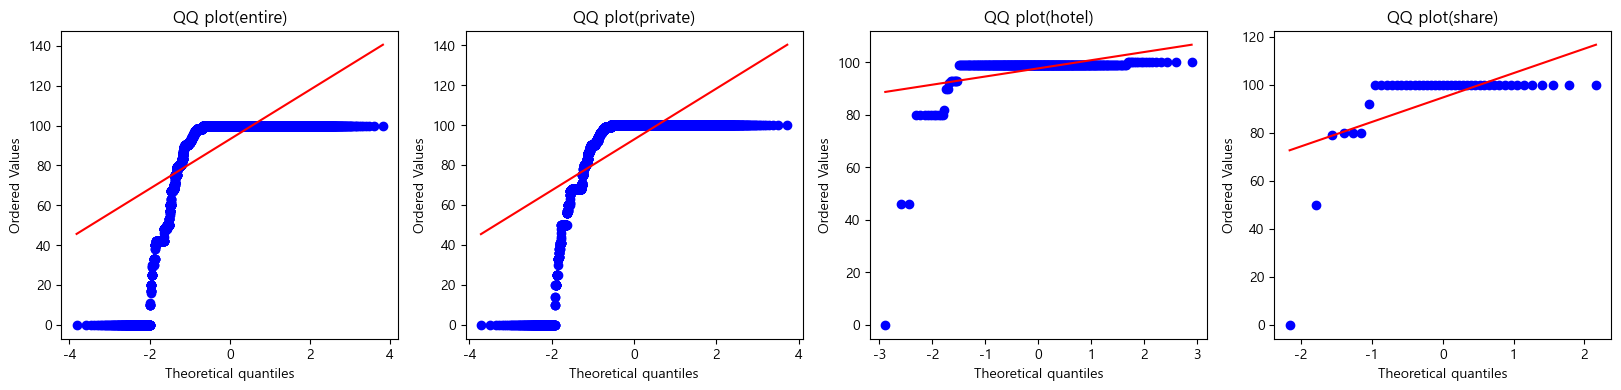

In [26]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(rt1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(rt2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(rt3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(rt4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

각 그룹의 분포가 직선에서 많이 벗어나 있어 정규성을 만족한다고 보기 어렵다.

In [27]:
# 크루스칼 검정 통계량, p-value 계산
stat, p = stats.kruskal(rt1, rt2, rt3,rt4)
stat, p

(np.float64(392.93692498357836), np.float64(7.499519146636976e-85))

p-value < 0.05 보다 낮으므로 귀무가설 기각.

귀무가설 : 숙소 유형별로 호스트 응답률의 평균은 모두 같다.<br>
대립가설 : 숙소 유형별로 호스트 응답률의 평균은 적어도 하나 이상 다르다.<br>
Q. 각 방 유형별로 호스트 응답률이 다 비슷비슷한가요?<br>

숙소 유형에 따라 호스트 응답률 분포가 모두 같다고 보기 어렵다.<br>
숙소 유형별로 호스트 응답률에 유의한 차이가 있다.<br>
아뇨. 적어도 한 유형은 다른 유형과 달라요. 즉, 방 유형에 따라 호스트 응답률에 차이가 있다.(관련있음) -> 어떤 방 유형이 차이가 <br>있는지? -> 사후검정 필요

### 사후검정

In [28]:
# Dunn 사후검정 
data = temp[['room_type', 'host_response_rate']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="host_response_rate",
                        group_col="room_type",
                        p_adjust="holm"
                        )

In [29]:
posthoc

,Entire home/apt,Hotel room,Private room,Shared room
Entire home/apt,1.000000e+00,2.310955e-85,1.285303e-04,1.893518e-01
Hotel room,2.310955e-85,1.000000e+00,1.886712e-74,9.767080e-15
Private room,1.285303e-04,1.886712e-74,1.000000e+00,1.659382e-01
Shared room,1.893518e-01,9.767080e-15,1.659382e-01,1.000000e+00


결과해석

p-value < 0.05 → 두 그룹 차이 있음<br>
p-value >= 0.05 → 두 그룹 차이 있다고 보기 어려움<br>
차이가 있는 조합<br>

Entire home/apt <-> Hotel room<br>
Entire home/apt <-> Private room<br>
Hotel room <-> Private room<br>
Hotel room <-> Shared room<br>
차이가 없는 조합<br>

Entire home/apt <-> Shared room<br>
Private room <-> Shared room<br>
Hotel room은 다른 방 유형과 유의한 차이를 보였고, Shared room은 Entire home/apt, Private room과는 유의한 차이가 나타나지 않았다.<br>

### 그렇다면.. 응답률은 가격에 영향을 미치는가?

In [30]:
rr_price = df[['host_response_rate', 'log_price']].copy()
rr_price = rr_price[(rr_price['host_response_rate'] != -1)].dropna()

<Axes: xlabel='host_response_rate', ylabel='log_price'>

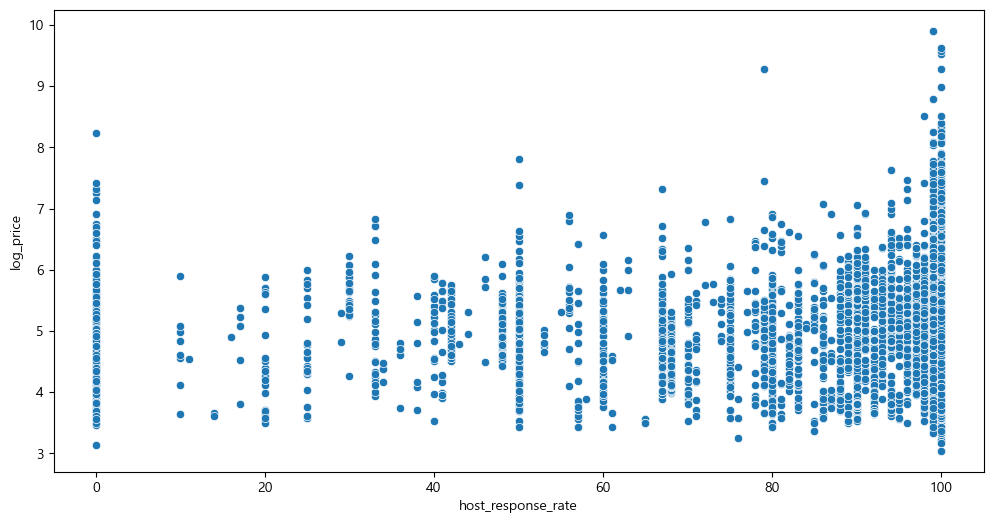

In [31]:
#산점도 확인
sns.scatterplot(data=rr_price, x='host_response_rate', y='log_price')

In [32]:
rr_price[['host_response_rate','log_price']].corr(method='pearson')

,host_response_rate,log_price
host_response_rate,1.000000,0.083587
log_price,0.083587,1.000000


In [33]:
rr_price[['host_response_rate','log_price']].corr(method='spearman')

,host_response_rate,log_price
host_response_rate,1.000000,0.112864
log_price,0.112864,1.000000


종합결론<Br>
그럼 결국 방 유형별로 호스트 응답률은 통계적으로 유의한 차이가 있었지만,<Br>
호스트 응답률이 가격 설정에 중요한 요인이라고 보기는 어렵다.<Br>

방 유형(Entire home/apt, Private room)에 따라 예약 요청 수락률에 차이가 있는가?<Br>
1. 가설설정 - 독립표본 t-test -> Mann-Whitney U검정<Br>
방 유형(Entire home/apt, Private room)에 따라 예약 요청 수락률에 차이가 있는가?<Br>
<Br>
귀무가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 없다.<Br>
대립가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 있다.<Br>
Entire home/apt,Private room<Br>

In [34]:
df_2group = df[df['room_type'].isin(['Entire home/apt', 'Private room'])]
df_2group['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Name: count, dtype: int64

In [35]:
display(df['host_acceptance_rate'].isna().sum())
display(df['host_acceptance_rate'].value_counts(dropna=False).head(10))

np.int64(0)

host_acceptance_rate
100.0    4888
87.0     3559
97.0     1407
99.0     1006
0.0       997
83.0      473
77.0      473
88.0      462
50.0      451
96.0      422
Name: count, dtype: int64

In [36]:
rh1 = df.loc[df['room_type']=='Entire home/apt','host_acceptance_rate'].dropna()
rh2 = df.loc[df['room_type']=='Private room','host_acceptance_rate'].dropna()

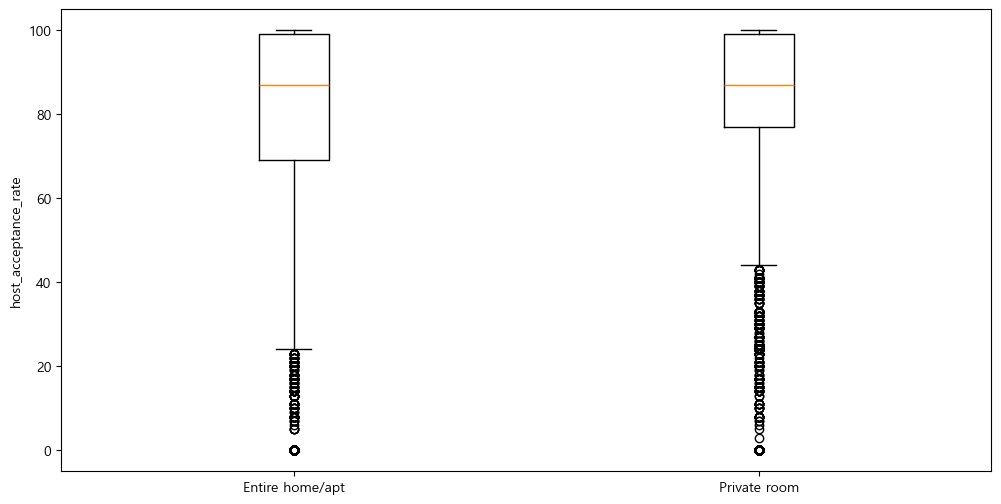

In [37]:
plt.boxplot([rh1, rh2], labels=['Entire home/apt', 'Private room'])
plt.ylabel('host_acceptance_rate')
plt.show()

In [38]:

rh1_group = rh1.sample(5000, random_state=42)
rh2_group = rh2.sample(5000, random_state=42)

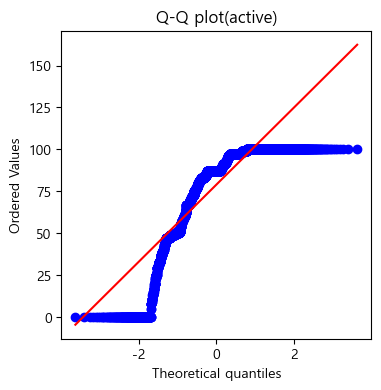

In [39]:
# 정규성 검정 1. Q-Q Plot

plt.figure(figsize=(4,4))
stats.probplot(rh1_group, plot=plt)
plt.title("Q-Q plot(active)")
plt.show()

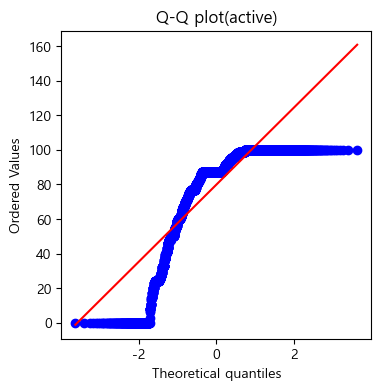

In [40]:

plt.figure(figsize=(4,4))
stats.probplot(rh2_group, plot=plt)
plt.title("Q-Q plot(active)")
plt.show()

In [41]:

# 표본 평균
sample_mean = np.mean(rh1_group)
# 표본 표준편차
s = np.std(rh1_group, ddof=1)

stat, p = stats.kstest(rh1_group, 'norm', args=(sample_mean, s))

stat, p
# 표본 평균
sample_mean = np.mean(rh1_group)
# 표본 표준편차
s = np.std(rh1_group, ddof=1)

stat, p = stats.kstest(rh1_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.217032594496277), np.float64(3.043176033504192e-207))

In [42]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(rh2_group)
# 표본 표준편차
s = np.std(rh2_group, ddof=1)

stat, p = stats.kstest(rh2_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.25177709624469996), np.float64(8.263711703044916e-280))

정규성 확인했을 때 정규성을 만족하지 않는다.
검정방법 선택 : 맨-휘트니 U-검정
유의수준 : 0.05로 결정

In [43]:
u_stat, u_p = stats.mannwhitneyu(rh1_group, rh2_group, alternative="two-sided")
u_stat, u_p

(np.float64(12245872.0), np.float64(0.07592475124704974))

결과해석<br>
p-value(0.075) > 유의수준(0.05) : 귀무가설을 기각하지 못함<br>

귀무가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 없다.<br>
대립가설 : Entire home/apt,Private room의 예약 요청 수락률 분포 차이가 있다.<br>
Q. 방 유형(Entire home/apt, Private room)에 따라 예약 요청 수락률에 차이가 있는가?<br>

검정 결과 p-value > 0.05 이므로 귀무가설을 기각하지 못했다.<br>
따라서 방 유형에 따라 예약 요청 수략률이 통계적으로 유의하게 다르다고 보기 어렵다.(차이가 있다고 할 만큼 근거를 찾지 못함.)<br>
지역에 따라 가격 차이 통계적 검증

가설설정<br>
귀무가설 : 지역(neighbourhood_group_cleansed)에 따라 가격 분포 차이가 없다.<br>
대립가설 : 지역에 따라 가격 분포 차이가 있다.<br>
검정방법<br>
후보 : 일원ANOVA -> 정규성 불만족 -> Kruskal-Wallis

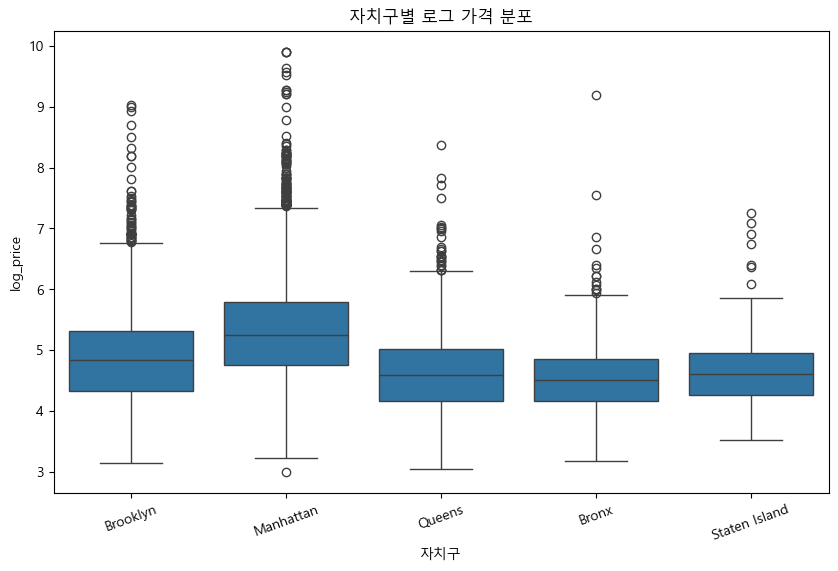

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='neighbourhood_group_cleansed', y='log_price')
plt.title('자치구별 로그 가격 분포')
plt.xlabel('자치구')
plt.ylabel('log_price')
plt.xticks(rotation=20)
plt.show()

<Axes: title={'center': 'log_price'}, xlabel='neighbourhood_group_cleansed'>

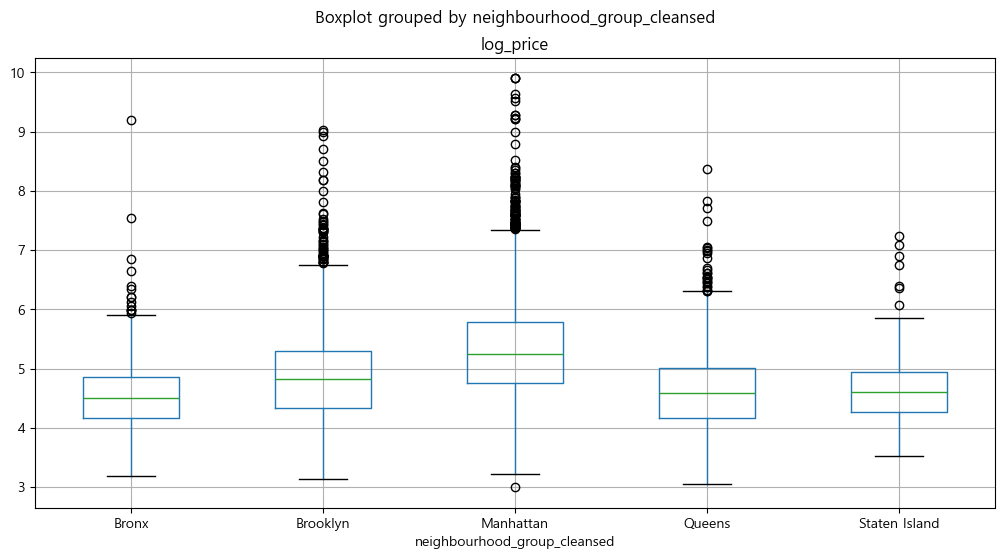

In [45]:
df.boxplot(column="log_price", by="neighbourhood_group_cleansed")

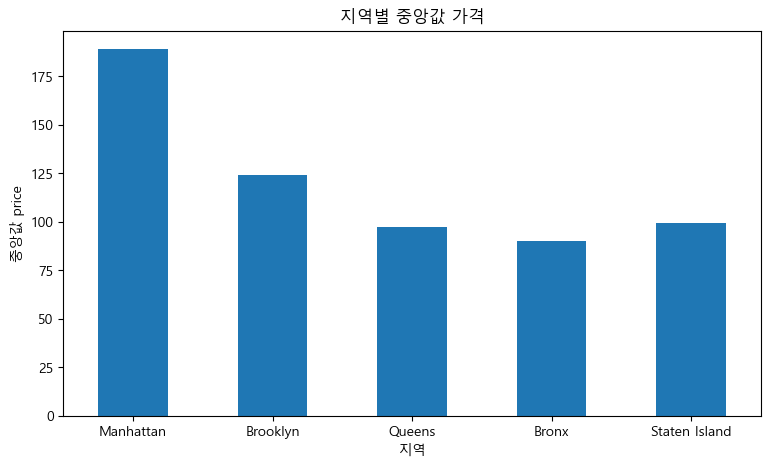

In [46]:
median_price = (
    df.groupby('neighbourhood_group_cleansed')['price']
      .median()
      .reindex(['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island'])
)

plt.figure(figsize=(9, 5))
median_price.plot(kind='bar')
plt.title('지역별 중앙값 가격')
plt.xlabel('지역')
plt.ylabel('중앙값 price')
plt.xticks(rotation=0)
plt.show()

In [47]:
nb1 = df.loc[df['neighbourhood_group_cleansed']=='Manhattan','log_price'].dropna()
nb2 = df.loc[df['neighbourhood_group_cleansed']=='Brooklyn','log_price'].dropna()
nb3 = df.loc[df['neighbourhood_group_cleansed']=='Queens','log_price'].dropna()
nb4 = df.loc[df['neighbourhood_group_cleansed']=='Bronx','log_price'].dropna()
nb5 = df.loc[df['neighbourhood_group_cleansed']=='Staten Island','log_price'].dropna()

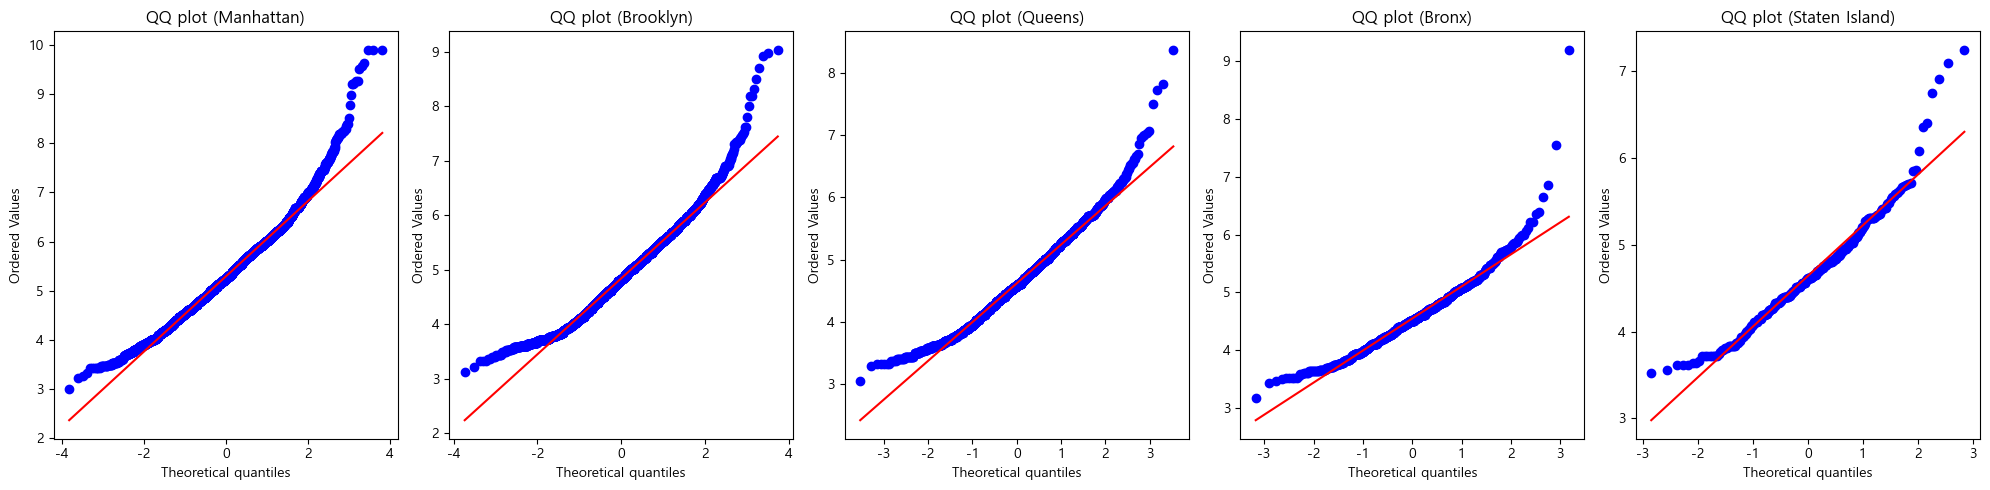

In [48]:
# q-q plot 시각화
fig, ax = plt.subplots(1, 5, figsize=(20, 5))

stats.probplot(nb1, plot=ax[0])
ax[0].set_title("QQ plot (Manhattan)")

stats.probplot(nb2, plot=ax[1])
ax[1].set_title("QQ plot (Brooklyn)")

stats.probplot(nb3, plot=ax[2])
ax[2].set_title("QQ plot (Queens)")

stats.probplot(nb4, plot=ax[3])
ax[3].set_title("QQ plot (Bronx)")

stats.probplot(nb5, plot=ax[4])
ax[4].set_title("QQ plot (Staten Island)")

plt.tight_layout()
plt.show()

In [49]:
# 크루스칼 검정 통계량, p-value 계산
stat, p = stats.kruskal(nb1, nb2, nb3,nb4,nb5)
stat, p

print(f"검정통계량 :",stat)
print(f"p-value: ", p)

검정통계량 : 3031.1794718296255
p-value:  0.0


p-value < 0.05 보다 낮으므로 귀무가설 기각.<Br>

해석 : 지역에 따라 가격 차이가 유의하게 있다.<br>
사후검정

In [50]:
data = df[['neighbourhood_group_cleansed', 'log_price']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="log_price",
                        group_col="neighbourhood_group_cleansed",
                        p_adjust="holm"
                        )
posthoc

,Bronx,Brooklyn,Manhattan,Queens,Staten Island
Bronx,1.000000e+00,1.442872e-34,5.414677e-185,2.496484e-03,1.105746e-01
Brooklyn,1.442872e-34,1.000000e+00,2.757203e-305,3.572843e-50,2.747754e-07
Manhattan,5.414677e-185,2.757203e-305,1.000000e+00,0.000000e+00,9.122648e-53
Queens,2.496484e-03,3.572843e-50,0.000000e+00,1.000000e+00,9.931252e-01
Staten Island,1.105746e-01,2.747754e-07,9.122648e-53,9.931252e-01,1.000000e+00


In [51]:
# 유의한 항목만
sig = posthoc < 0.05
sig

,Bronx,Brooklyn,Manhattan,Queens,Staten Island
Bronx,False,True,True,True,False
Brooklyn,True,False,True,True,True
Manhattan,True,True,False,True,True
Queens,True,True,True,False,False
Staten Island,False,True,True,False,False


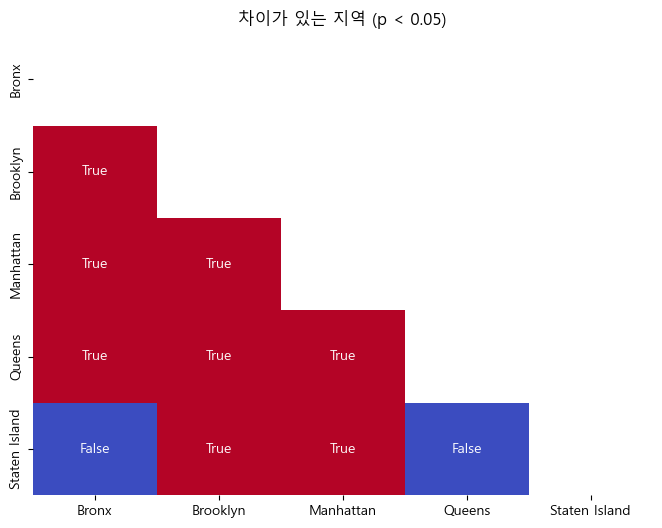

In [52]:
plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(sig, dtype=bool))

sns.heatmap(
    sig,
    annot=True,
    fmt="",
    cmap="coolwarm",
    mask=mask,
    cbar=False
)

plt.title("차이가 있는 지역 (p < 0.05)")
plt.show()

결과해석<br>

p-value < 0.05 → 두 지역 간 차이가 유의하다<br>
p-value >= 0.05 → 두 지역 간 차이가 유의하지않다.<br>
유의한 있는 조합<br>

Bronx vs Brooklyn<br>
Bronx vs Manhattan<br>
Brooklyn vs Manhattan<br>
Brooklyn vs Queens<br>
Brooklyn vs Staten Island<br>
Manhattan vs Queens<br>
Manhattan vs Staten Island<br>
유의하지 않은 조합<br>

Bronx vs Staten Island<br>
Queens vs Staten Island<br>
대부분 지역 간 가격 차이는 유의했지만, Bronx–Staten Island, Queens–Staten Island는 유의한 차이가 없었다.

In [53]:
df.groupby('neighbourhood_group_cleansed')['price'].median().sort_values(ascending=False)

neighbourhood_group_cleansed
Manhattan        189.0
Brooklyn         124.0
Staten Island     99.5
Queens            97.0
Bronx             90.0
Name: price, dtype: float64

In [54]:
df.groupby('neighbourhood_group_cleansed')['log_price'].median().sort_values(ascending=False)

neighbourhood_group_cleansed
Manhattan        5.247024
Brooklyn         4.828314
Staten Island    4.610145
Queens           4.584967
Bronx            4.510860
Name: log_price, dtype: float64

In [55]:
df_clean = pd.read_csv("data/first_clean_data.csv")
clean = df_clean.copy()

In [56]:
from scipy.stats import chi2_contingency

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

In [57]:
ct = pd.crosstab(clean['room_type'], clean['neighbourhood_group_cleansed'])
cramers_v(ct)

np.float64(0.15705648117352444)

In [58]:
ct2 = pd.crosstab(clean['room_type'], clean['host_is_superhost'])
cramers_v(ct2)

np.float64(0.06156069544850748)

In [59]:
ct3 = pd.crosstab(clean['room_type'], clean['property_type'])
cramers_v(ct3)

np.float64(0.8838083381858214)

범주 vs 수치로 ANOVA 검정 실행<br>
room_type vs 수용인원<br>
room_type vs 침실수<br>
room_type vs 침대수 흠.... 나머지는 모르겠음....<br>
가설 설정<br>
귀무가설 : 방 유형별로 수용인원의 차이가 없다.<br>
대립가설 : 방 유형별로 수용인원이 1개라도 차이가 있다.<br>
3그룹 이상 각각 구하는거니 일원 anova 정규성 검정

In [60]:
ac1 = clean.loc[clean['room_type'] == 'Entire home/apt', 'accommodates']
ac2 = clean.loc[clean['room_type'] == 'Private room', 'accommodates']
ac3 = clean.loc[clean['room_type'] == 'Hotel room', 'accommodates']
ac4 = clean.loc[clean['room_type'] == 'Shared room', 'accommodates']

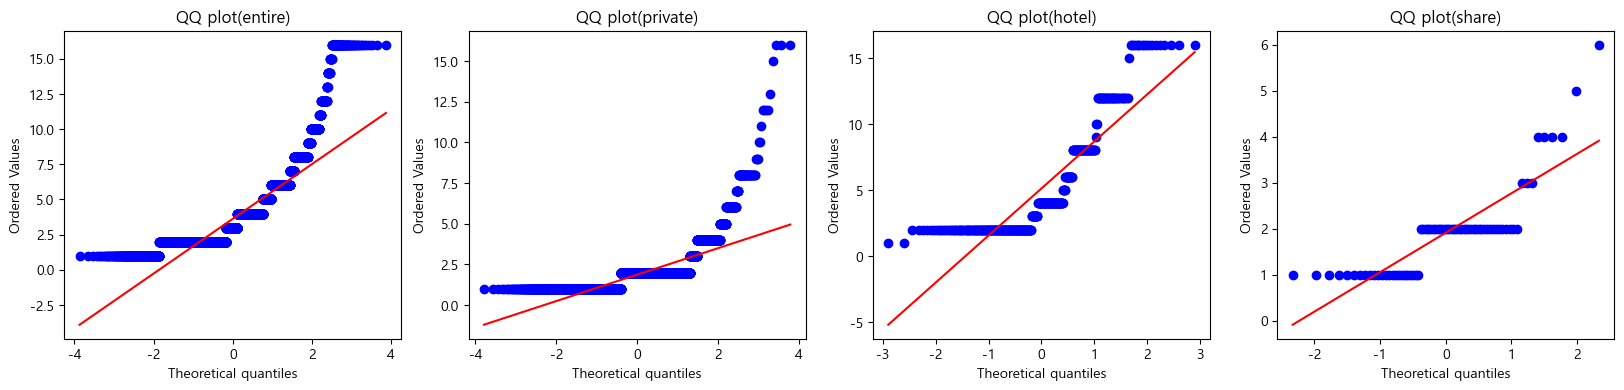

In [61]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(ac1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(ac2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(ac3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(ac4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

정규성을 띄지않아서 크루스칼 왈리스로 p-value 확인

In [62]:
stat, p = stats.kruskal(ac1, ac2, ac3, ac4)
stat, p

(np.float64(6648.260919820135), np.float64(0.0))

유의 수준 0.05로 잡고 확인

확인 결과: p-value 0.0으로 0에 매우 근접해서 유의수준에 한참 미치지 못해 귀무가설 기각<br>
그러므로 대립가설 채택<br>
결론: 방 유형별로 수용인원의 차이가 있다.<br>
사후검정(dunn test)

In [63]:
import scikit_posthocs as sp

data = pd.DataFrame({
    'value': pd.concat([ac1, ac2, ac3, ac4]),
    'group': ['Entire home']*len(ac1) + ['Private room']*len(ac2) + 
             ['Hotel room']*len(ac3) + ['Shared room']*len(ac4)
})

posthoc = sp.posthoc_dunn(data,
                          val_col='value',
                          group_col='group',
                          p_adjust='holm')
print(posthoc)

               Entire home     Hotel room   Private room   Shared room
Entire home   1.000000e+00   9.121861e-04   0.000000e+00  2.458253e-18
Hotel room    9.121861e-04   1.000000e+00  3.132237e-128  4.611173e-21
Private room  0.000000e+00  3.132237e-128   1.000000e+00  7.284464e-01
Shared room   2.458253e-18   4.611173e-21   7.284464e-01  1.000000e+00


private room -> shared room은 숙소유형별 수용인원 차이가 없다.(0.728)<br>
나머지는 숙소유형별 차이가 있다.<br>

room_type vs 침실 수 ANOVA 검정<br>
가설 설정<br>
귀무가설: 방 유형별로 침실 수가 차이가 없다.<br>
대립가설: 방 유형별로 침실 수가 1개라도 차이가 있다.

In [64]:
clean['bedrooms'].isna().sum()

np.int64(0)

In [65]:
clean['bedrooms'] = clean['bedrooms'].astype(int)

In [66]:
bed1 = clean.loc[clean['room_type'] == 'Entire home/apt', 'bedrooms']
bed2 = clean.loc[clean['room_type'] == 'Private room', 'bedrooms']
bed3 = clean.loc[clean['room_type'] == 'Hotel room', 'bedrooms']
bed4 = clean.loc[clean['room_type'] == 'Shared room', 'bedrooms']

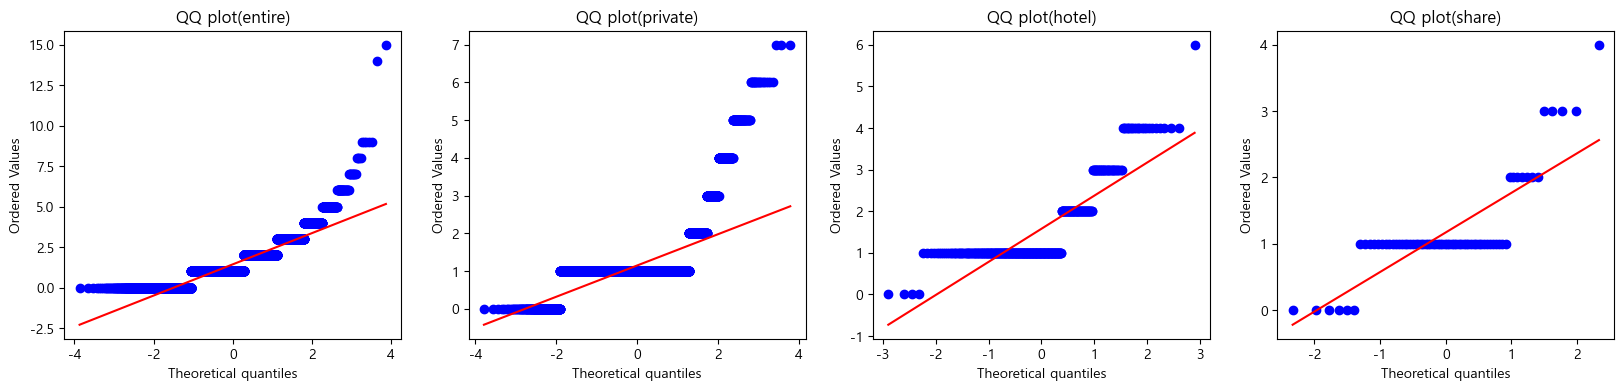

In [67]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(bed1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(bed2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(bed3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(bed4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

정규성을 띄지 않아 크루스칼 왈리스(유의수준 0.05로 잡음)

In [68]:
stat, p = stats.kruskal(bed1, bed2, bed3, bed4)
stat, p

(np.float64(669.6543124602632), np.float64(7.978589906254915e-145))

p-value의 값이 0에 가까운 값이므로 유의수준보다 한참 못 미쳐 귀무가설 기각 대립가설 채택

결론: 방 유형별로 침실 수가 1개라도 차이가 있다.
마지막 사후 검정(dunn test)

In [69]:
data = pd.DataFrame({
    'value': pd.concat([bed1, bed2, bed3, bed4]),
    'group': ['Entire home']*len(bed1) + ['Private room']*len(bed2) + 
             ['Hotel room']*len(bed3) + ['Shared room']*len(bed4)
})

posthoc = sp.posthoc_dunn(data,
                          val_col='value',
                          group_col='group',
                          p_adjust='holm')
print(posthoc)

                Entire home    Hotel room   Private room  Shared room
Entire home    1.000000e+00  6.856089e-03  4.063005e-139     0.024873
Hotel room     6.856089e-03  1.000000e+00   1.004390e-20     0.001618
Private room  4.063005e-139  1.004390e-20   1.000000e+00     0.702913
Shared room    2.487341e-02  1.618043e-03   7.029134e-01     1.000000


결과: 수용인원이랑 똑같이 private room이랑 shared room만 차이가 없다라고 나오고 나머지는 차이가 있다라고 나옴...
# room_type vs 침대 수 ANOVA 검정
가설설정<br>
귀무가설: 방 유형별 침대수의 차이가 없다.<br>
대립가설: 방 유형별 침대수가 1개라도 차이가 있다.

In [70]:
clean['beds'].isna().sum()

np.int64(0)

In [71]:
clean['beds'] = clean['beds'].astype(int)

In [72]:
clean['beds'].value_counts()

beds
1     13014
2      5132
3      1893
4       911
0       634
5       328
6       180
7        66
8        54
9        17
10        7
12        4
13        3
11        2
42        1
14        1
21        1
Name: count, dtype: int64

In [73]:
beds1 = clean.loc[clean['room_type'] == 'Entire home/apt', 'beds']
beds2 = clean.loc[clean['room_type'] == 'Private room', 'beds']
beds3 = clean.loc[clean['room_type'] == 'Hotel room', 'beds']
beds4 = clean.loc[clean['room_type'] == 'Shared room', 'beds']

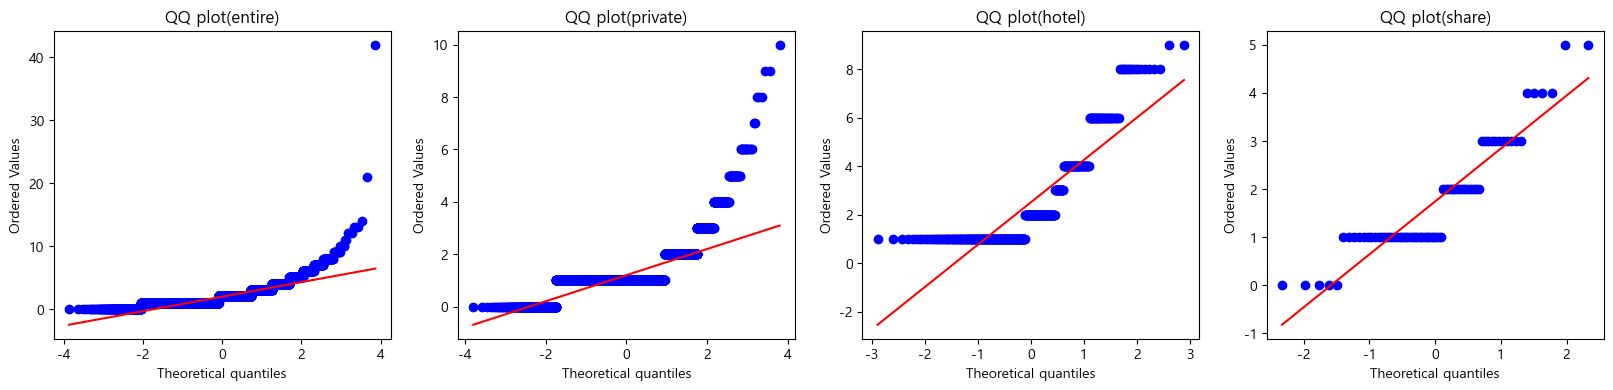

In [74]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(beds1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(beds2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(beds3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(beds4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

계단식 형태로 정규성 안뜀 1번사진이 4개중에 괜찮은 느낌?

그러므로 크루스칼 왈리스 시행(유의수준은 0.05)

In [75]:
stat, p = stats.kruskal(beds1, beds2, beds3, beds4)
stat, p

(np.float64(3064.47174802314), np.float64(0.0))

0.0으로 유의수준에 못미쳐서 귀무가설 기각 대립가설 채택 결론: 방 유형별로 침대수가 차이가 있다.

사후검정(어떤게 차이가 있는지 없는지 dunn test)

In [76]:
data = pd.DataFrame({
    'value': pd.concat([beds1, beds2, beds3, beds4]),
    'group': ['Entire home']*len(beds1) + ['Private room']*len(beds2) + 
             ['Hotel room']*len(beds3) + ['Shared room']*len(beds4)
})

posthoc = sp.posthoc_dunn(data,
                          val_col='value',
                          group_col='group',
                          p_adjust='holm')
print(posthoc)

              Entire home    Hotel room  Private room  Shared room
Entire home      1.000000  1.474208e-02  0.000000e+00     0.112823
Hotel room       0.014742  1.000000e+00  6.262106e-63     0.018594
Private room     0.000000  6.262106e-63  1.000000e+00     0.000012
Shared room      0.112823  1.859419e-02  1.249233e-05     1.000000


결과: shared room과 entire home은 유의수준 0.112로 0.05보다 높으므로 차이가 없다라고 볼 수 있다. 나머지는 차이가 있다.(침대 수)

In [77]:
print(clean.groupby('room_type')['bedrooms'].mean())
print(clean.groupby('room_type')['beds'].mean())

room_type
Entire home/apt    1.430708
Hotel room         1.578082
Private room       1.146655
Shared room        1.171429
Name: bedrooms, dtype: float64
room_type
Entire home/apt    1.945865
Hotel room         2.504110
Private room       1.198736
Shared room        1.742857
Name: beds, dtype: float64


In [78]:
clean[['accommodates', 'bedrooms', 'beds', 'log_price']].corr(method='pearson')

,accommodates,bedrooms,beds,log_price
accommodates,1.000000,0.595693,0.734593,0.508829
bedrooms,0.595693,1.000000,0.641898,0.296522
beds,0.734593,0.641898,1.000000,0.381284
log_price,0.508829,0.296522,0.381284,1.000000


보니 전체적으로 3개다 price랑 약한 상관관계가 보이고 accommodates는 그중 0.283으로 젤 높은 상관관계를 뛴다.

호스트 응답률별 가격 통계 검정(수치vs수치 이므로 pearson), 유의수준 0.05<br>
호스트 응답률과 가격간의 차이를 보기위해 피어슨으로 상관관계부터 확인

In [79]:
clean['host_response_rate'].corr(clean['log_price'])

np.float64(0.003064356648582748)

<Axes: xlabel='host_response_rate', ylabel='log_price'>

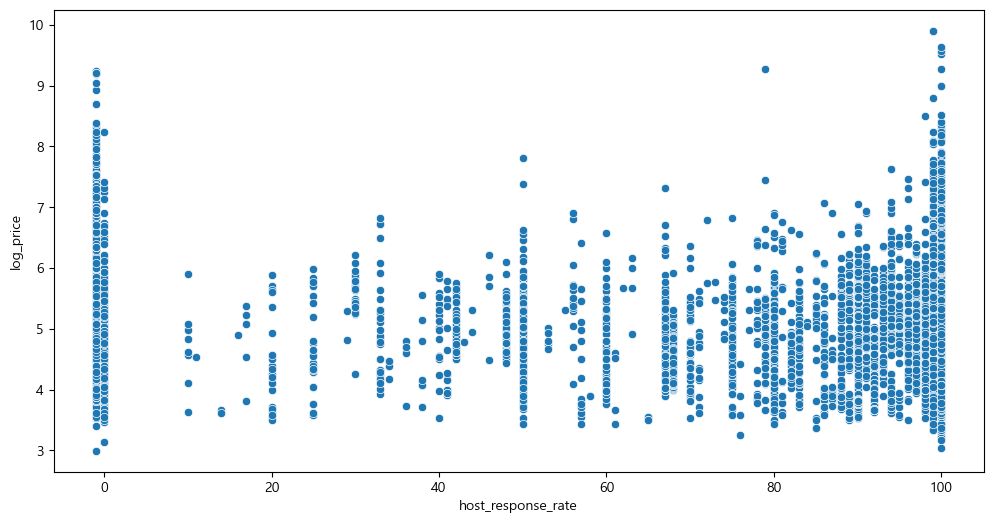

In [80]:
sns.scatterplot(data=clean, x='host_response_rate', y='log_price')

In [81]:
clean['host_acceptance_rate'].corr(clean['log_price'])

np.float64(0.09463012881439758)

<Axes: xlabel='host_acceptance_rate', ylabel='log_price'>

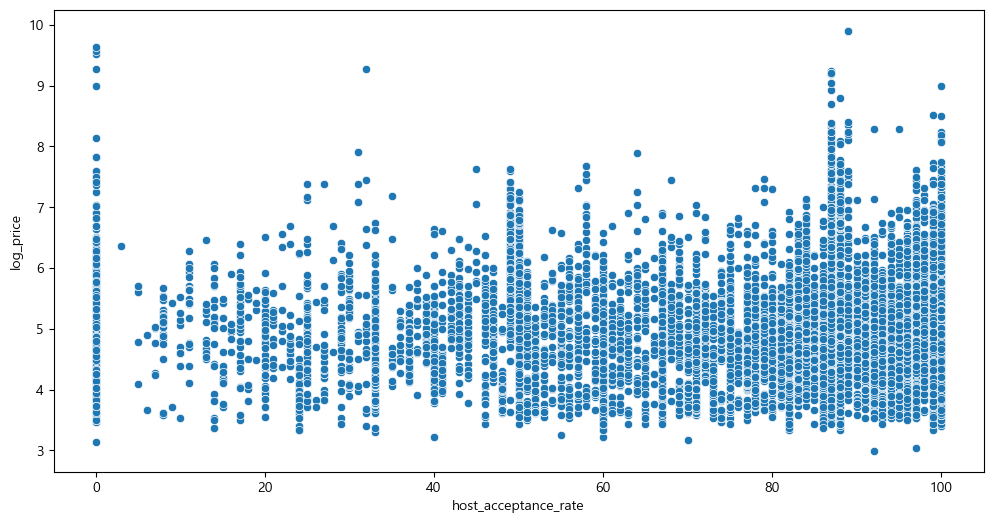

In [82]:
sns.scatterplot(data=clean, x='host_acceptance_rate', y='log_price')

In [83]:
clean_response = clean[clean['host_response_rate'] >= 0]

In [84]:
clean_response['response_group'] = pd.cut(clean_response['host_response_rate'], bins=[0,50,90,100], labels=['low', 'mid', 'high'], include_lowest=True)

In [85]:
clean_response.groupby('response_group')['log_price'].mean()

response_group
low     4.844958
mid     4.723559
high    5.025156
Name: log_price, dtype: float64

In [86]:
clean_response.groupby('response_group')['log_price'].describe()

,count,mean,std,min,25%,50%,75%,max
response_group,,,,,,,,
low,1045.0,4.844958,0.657592,3.135494,4.394449,4.812184,5.214936,8.237744
mid,1722.0,4.723559,0.663760,3.258097,4.262680,4.644391,5.111988,9.274723
high,15092.0,5.025156,0.795755,3.044522,4.454347,5.010635,5.564520,9.903538


확실히 응답률이 100%일때의 가격이 5.02로 가장 높다.<Br>
그래서 구간을 3개로 나눠 그룹해서 anova 검정<br>
가설 설정<br>
귀무가설: 응답률 그룹별로 가격간의 차이가 없다.<Br>
대립가설: 응답률 그룹별로 가격간의 차이가 적어도 1개라도 있다.<br>

In [87]:
low = clean_response[clean_response['response_group']=='low']['log_price']
mid = clean_response[clean_response['response_group']=='mid']['log_price']
high = clean_response[clean_response['response_group']=='high']['log_price']

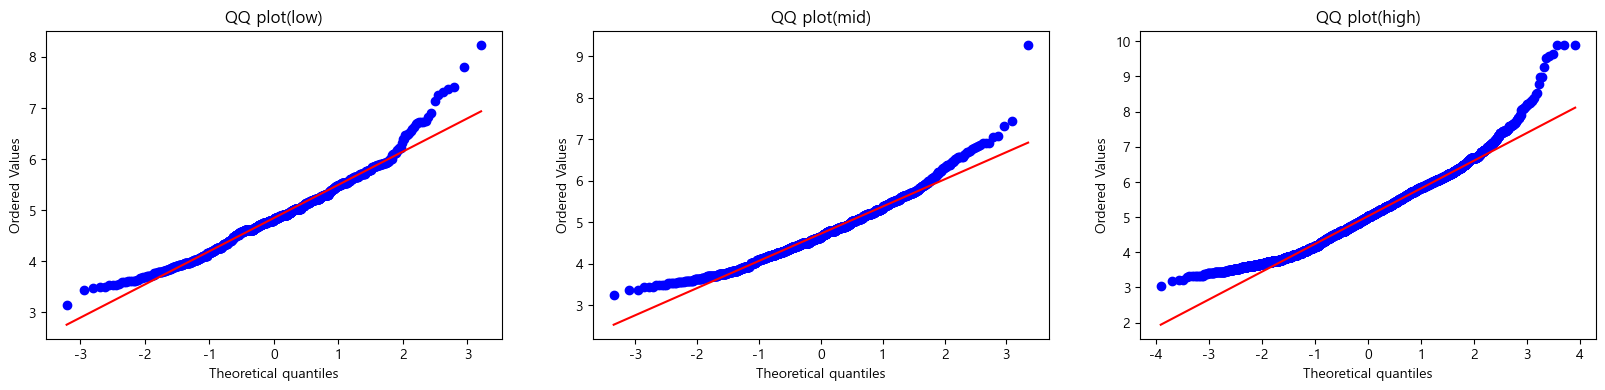

In [88]:
# 일원 anova(정규성 검정 q-q plot)
fig, ax = plt.subplots(1,3, figsize=(20,4))
stats.probplot(low, plot=ax[0])
ax[0].set_title("QQ plot(low)")
stats.probplot(mid, plot=ax[1])
ax[1].set_title("QQ plot(mid)")
stats.probplot(high, plot=ax[2])
ax[2].set_title("QQ plot(high)")
plt.show()

In [89]:
# 유의수준 0.05
stat, p = stats.kruskal(low, mid, high)
stat, p

(np.float64(286.90236843008324), np.float64(5.01120619489422e-63))

In [90]:
if p < 0.05:
    print("그룹 간 가격 차이 있음")
else:
    print("그룹 간 가격 차이 없음")

그룹 간 가격 차이 있음


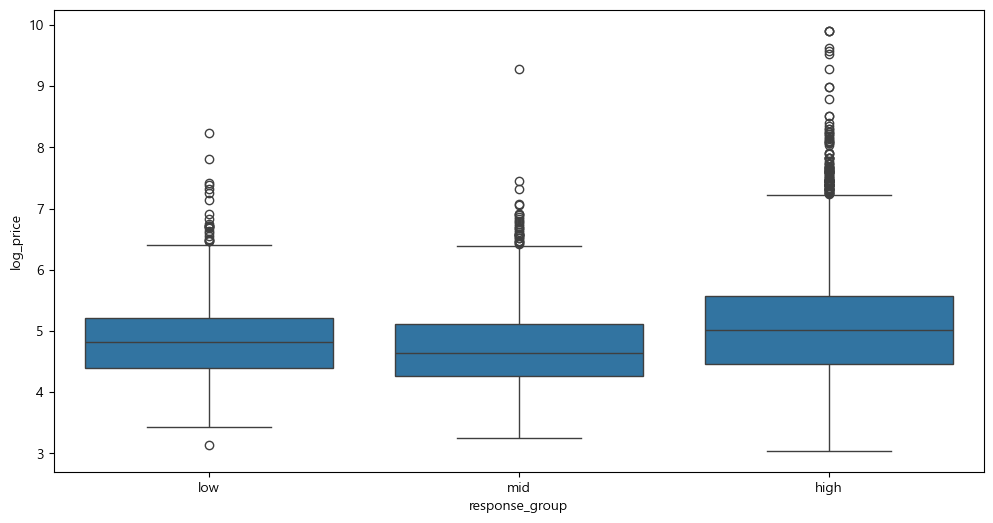

In [91]:
# 호스트 응답률별로 어떤그룹의 차이가 젤 높은지 확인하기 위한 boxplot
sns.boxplot(x='response_group', y='log_price', data=clean_response)
plt.show()

In [92]:
import scikit_posthocs as sp

sp.posthoc_dunn(
    clean_response,
    val_col='log_price',
    group_col='response_group',
    p_adjust='bonferroni'
)

,low,mid,high
low,1.000000e+00,2.712149e-05,2.070674e-12
mid,2.712149e-05,1.000000e+00,2.861090e-56
high,2.070674e-12,2.861090e-56,1.000000e+00


사후검정까지 확인한 결과 세 그룹 모두 서로 통계적으로 차이가 있다.

In [93]:
df_cleaned = pd.read_csv("data/first_clean_data.csv")
# 1. 25~50번째 컬럼 슬라이싱 + review_scores_rating 포함
target_columns = list(df_cleaned.columns) 
if 'review_scores_rating' not in target_columns:
    target_columns.append('review_scores_rating')

# 2. 그 중 수치형 데이터만 추출
numeric_df = df_cleaned[target_columns].select_dtypes(include=['number'])

# 3. 스피어만 상관계수 계산 (이상치에 강함)
review_scores_rating_corr = numeric_df.corr(method='spearman')['review_scores_rating'].sort_values(ascending=False)

print("--- 평점과 상관관계가 높은 주요 변수 ---")
print(review_scores_rating_corr)

--- 평점과 상관관계가 높은 주요 변수 ---
review_scores_rating                            1.000000
review_scores_accuracy                          0.778852
review_scores_value                             0.711800
review_scores_cleanliness                       0.707056
review_scores_communication                     0.691476
review_scores_checkin                           0.647184
review_scores_location                          0.473748
id                                              0.129799
Unnamed: 0                                      0.129747
log_price                                       0.100145
price                                           0.100145
host_response_rate                              0.069837
bedrooms                                        0.059570
estimated_revenue_l365d                         0.041775
estimated_occupancy_l365d                       0.010973
longitude                                       0.008880
host_response_time                              0.001071
calc

평점 4.8점 이상, 이하로 나눠서 두 집단 비교

In [94]:
# test_df1을 새로 만들고 거기에 평균 4.8이상/미만 파생컬럼 생성

# 결측치 제거(평점이 null일때 무언가로 채우면 안될거같아서 과감히 빼버리기로 함)
test_df1 = df_cleaned.dropna(subset=['review_scores_rating']).copy()

# 파생 컬럼 생성
test_df1['rating_group'] = 'Low'
test_df1.loc[test_df1['review_scores_rating'] >= 4.8, 'rating_group'] = 'High'
print(test_df1['rating_group'].value_counts())

rating_group
High    9122
Low     6364
Name: count, dtype: int64


1. 두 집단별 방 유형 상관정도 구하기(카이제곱 검정과 크래머 V 계수 구하기)

In [95]:
ct_room = pd.crosstab(test_df1['room_type'],test_df1['rating_group'])
result = chi2_contingency(ct_room)
result

Chi2ContingencyResult(statistic=np.float64(34.39724235899625), pvalue=np.float64(1.6332471573893443e-07), dof=3, expected_freq=array([[5214.25442335, 3637.74557665],
       [  67.15149167,   46.84850833],
       [3807.01833915, 2655.98166085],
       [  33.57574583,   23.42425417]]))

In [96]:
ct_room

rating_group,High,Low
room_type,,
Entire home/apt,5353,3499
Hotel room,48,66
Private room,3682,2781
Shared room,39,18


In [97]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

cramers_v(ct_room)

np.float64(0.047129429832478476)

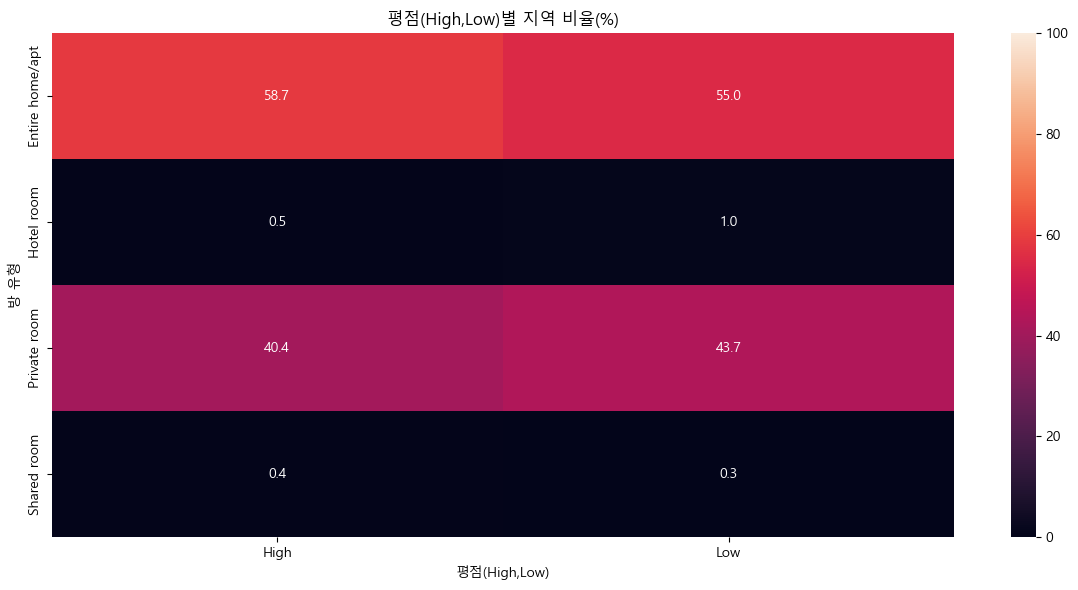

In [98]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct_room_percent = ct_room.div(ct_room.sum(axis=0), axis=1) * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct_room_percent, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("평점(High,Low)별 지역 비율(%)")
plt.xlabel("평점(High,Low)")
plt.ylabel("방 유형")
plt.tight_layout()
plt.show()

In [99]:
ct = pd.crosstab(test_df1['room_type'], test_df1['rating_group'])
ct_2 = ct.loc[~ct.index.isin(['Hotel room','Shared room'])]
ct_2

rating_group,High,Low
room_type,,
Entire home/apt,5353,3499
Private room,3682,2781


In [100]:
result = chi2_contingency(ct_2)
result

Chi2ContingencyResult(statistic=np.float64(18.791081253940018), pvalue=np.float64(1.4584756065132334e-05), dof=1, expected_freq=array([[5222.18870389, 3629.81129611],
       [3812.81129611, 2650.18870389]]))

In [101]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v


cramers_ct_2 = cramers_v(ct_2)
print(f'크래머 V 계수: {cramers_ct_2}')

크래머 V 계수: 0.035028164829252154


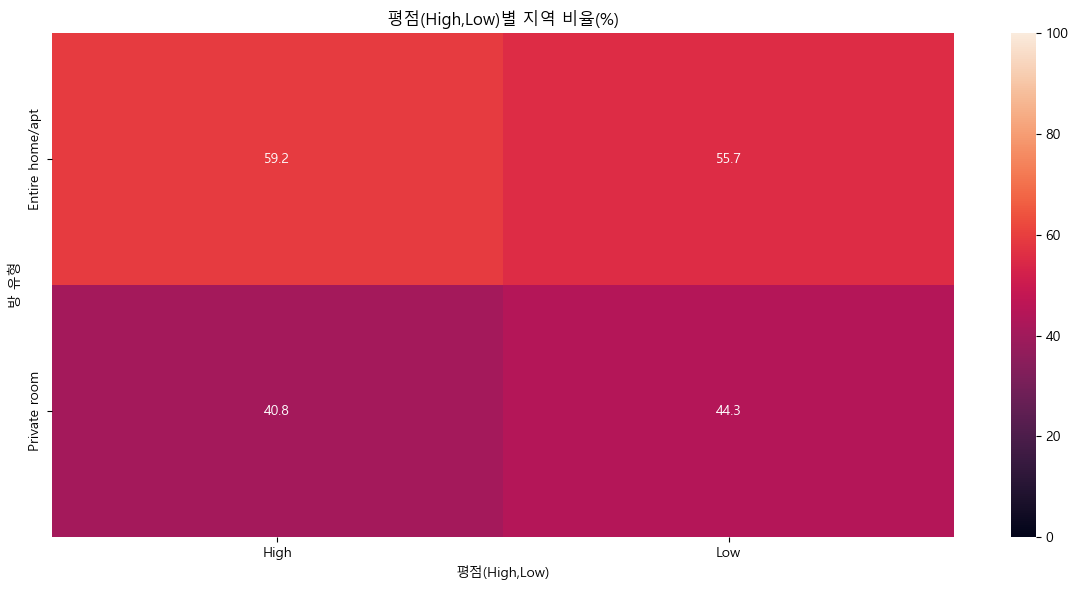

In [102]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct_2_percent = ct_2.div(ct_2.sum(axis=0), axis=1) * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct_2_percent, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("평점(High,Low)별 지역 비율(%)")
plt.xlabel("평점(High,Low)")
plt.ylabel("방 유형")
plt.tight_layout()
plt.show()

2. 두 집단별 지역 상관정도 구하기(카이제곱 검정과 크래머 V 계수 구하기)

In [103]:
ct_neighbourhood = pd.crosstab(test_df1['neighbourhood_group_cleansed'],test_df1['rating_group'])
result = chi2_contingency(ct_neighbourhood)
result

Chi2ContingencyResult(statistic=np.float64(202.40815038791274), pvalue=np.float64(1.1405039925805603e-42), dof=4, expected_freq=array([[ 414.68991347,  289.31008653],
       [3300.43691076, 2302.56308924],
       [3667.41392225, 2558.58607775],
       [1591.01911404, 1109.98088596],
       [ 148.44013948,  103.55986052]]))

In [104]:
ct_neighbourhood

rating_group,High,Low
neighbourhood_group_cleansed,,
Bronx,397,307
Brooklyn,3665,1938
Manhattan,3285,2941
Queens,1609,1092
Staten Island,166,86


In [105]:
# Cramer's V
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v


cramers = cramers_v(ct_neighbourhood)
print(f'크래머 V 계수: {cramers}')

크래머 V 계수: 0.1143258320173284


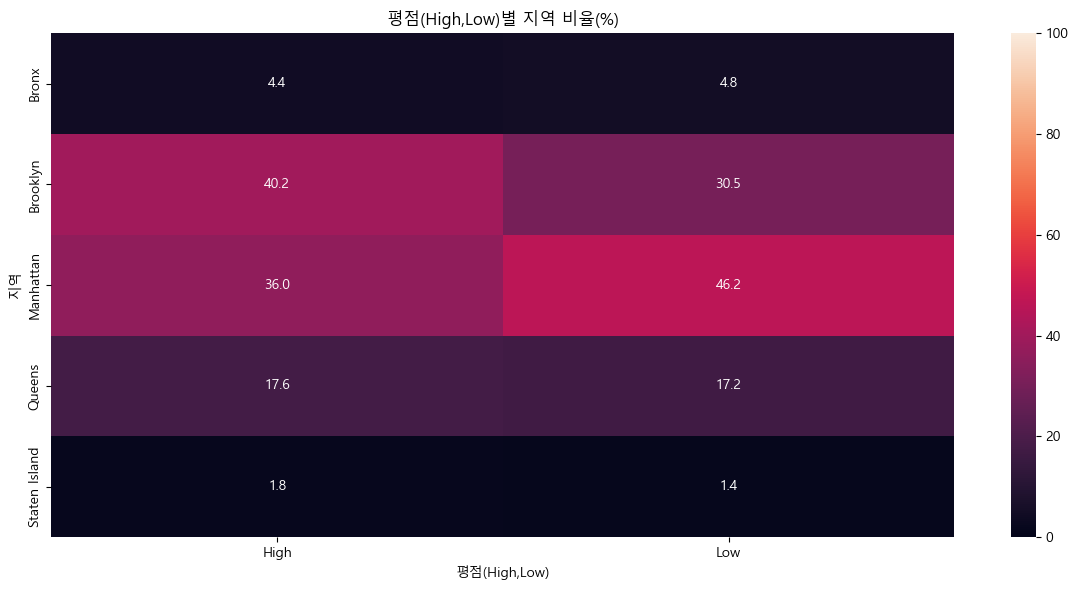

In [106]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct_neighbourhood_percent = ct_neighbourhood.div(ct_neighbourhood.sum(axis=0), axis=1) * 100
# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct_neighbourhood_percent, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("평점(High,Low)별 지역 비율(%)")
plt.xlabel("평점(High,Low)")
plt.ylabel("지역")
plt.tight_layout()
plt.show()

Entire Home 데이터 개수: 12635
Private Room 데이터 개수: 9178


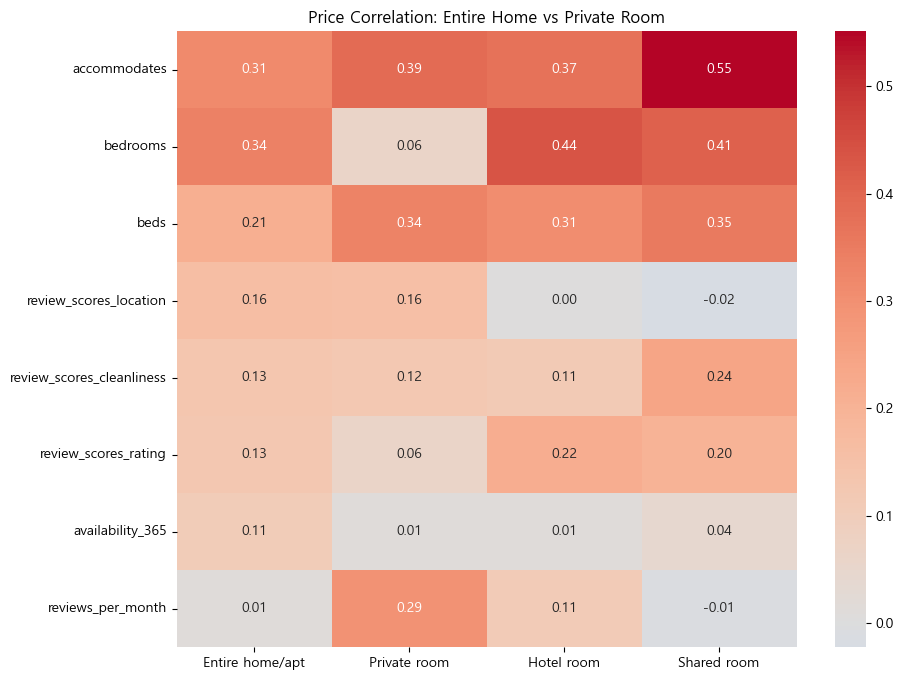

In [107]:
target_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 
    'review_scores_location', 'review_scores_cleanliness', 
    'review_scores_rating', 'availability_365', 'reviews_per_month'
]

private_df = df_cleaned[df_cleaned['room_type'] == 'Private room'][target_cols]
entire_df = df_cleaned[df_cleaned['room_type'] == 'Entire home/apt'][target_cols]
Hotel_df = df_cleaned[df_cleaned['room_type'] == 'Hotel room'][target_cols]
Shared_df = df_cleaned[df_cleaned['room_type'] == 'Shared room'][target_cols]

# 데이터 개수 확인 (신뢰도 체크)
print(f"Entire Home 데이터 개수: {len(entire_df)}")
print(f"Private Room 데이터 개수: {len(private_df)}")

# 3. 그룹별 스피어만 상관계수 계산
private_corr = private_df.corr(method='spearman')['price'].rename('Private room')
entire_corr = entire_df.corr(method='spearman')['price'].rename('Entire home/apt')
Hotel_df = Hotel_df.corr(method='spearman')['price'].rename('Hotel room')
Shared_df = Shared_df.corr(method='spearman')['price'].rename('Shared room')

# 4. 결과 합치기
comparison_df = pd.concat([entire_corr, private_corr, Hotel_df, Shared_df], axis=1).drop('price') # 'price' 자기 자신은 제외

# 5. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Price Correlation: Entire Home vs Private Room')
plt.show()

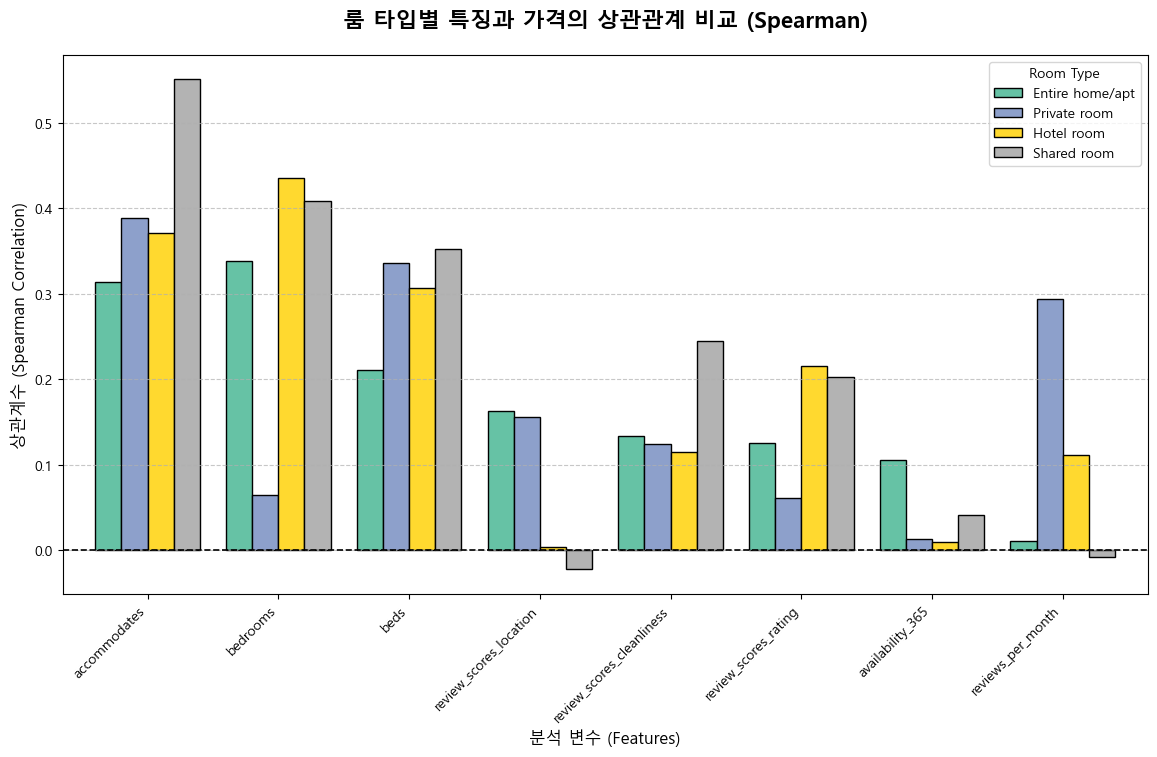

In [108]:
# 1. 비교할 타겟 컬럼 선정
target_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 
    'review_scores_location', 'review_scores_cleanliness', 
    'review_scores_rating', 'availability_365', 'reviews_per_month'
]

# 2. 룸 타입별 데이터 분리
private_df = df_cleaned[df_cleaned['room_type'] == 'Private room'][target_cols]
entire_df = df_cleaned[df_cleaned['room_type'] == 'Entire home/apt'][target_cols]
hotel_df = df_cleaned[df_cleaned['room_type'] == 'Hotel room'][target_cols]
shared_df = df_cleaned[df_cleaned['room_type'] == 'Shared room'][target_cols]

# 3. 그룹별 스피어만 상관계수 계산 (변수명 오류 수정)
private_corr = private_df.corr(method='spearman')['price'].rename('Private room')
entire_corr = entire_df.corr(method='spearman')['price'].rename('Entire home/apt')
hotel_corr = hotel_df.corr(method='spearman')['price'].rename('Hotel room')
shared_corr = shared_df.corr(method='spearman')['price'].rename('Shared room')

# 4. 결과 합치기 ('price' 자기 자신은 제외)
comparison_df = pd.concat([entire_corr, private_corr, hotel_corr, shared_corr], axis=1).drop('price')

# 5. 막대 차트 시각화
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# Pandas의 내장 plot 함수를 사용하여 그룹 막대 차트 생성
# colormap='Set2'를 사용해 프레젠테이션에 어울리는 세련된 파스텔 톤 적용
ax = comparison_df.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='Set2', edgecolor='black')

# 그래프 디테일 꾸미기
plt.title('룸 타입별 특징과 가격의 상관관계 비교 (Spearman)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('분석 변수 (Features)', fontsize=12)
plt.ylabel('상관계수 (Spearman Correlation)', fontsize=12)

# x축 라벨(컬럼명)이 길어서 겹치지 않도록 45도 회전
plt.xticks(rotation=45, ha='right')

# 0을 기준으로 양수/음수를 명확히 구분하는 가로 기준선 추가
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')

# 배경에 연한 그리드를 깔아 수치 비교를 쉽게 만들기
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 범례(Legend) 설정
plt.legend(title='Room Type', fontsize='10', loc='upper right')

# 캔바 프레젠테이션 및 티스토리 업로드용 고화질(300 dpi) 이미지 저장
plt.savefig('room_type_bar_chart.png', dpi=300, bbox_inches='tight')

plt.show()

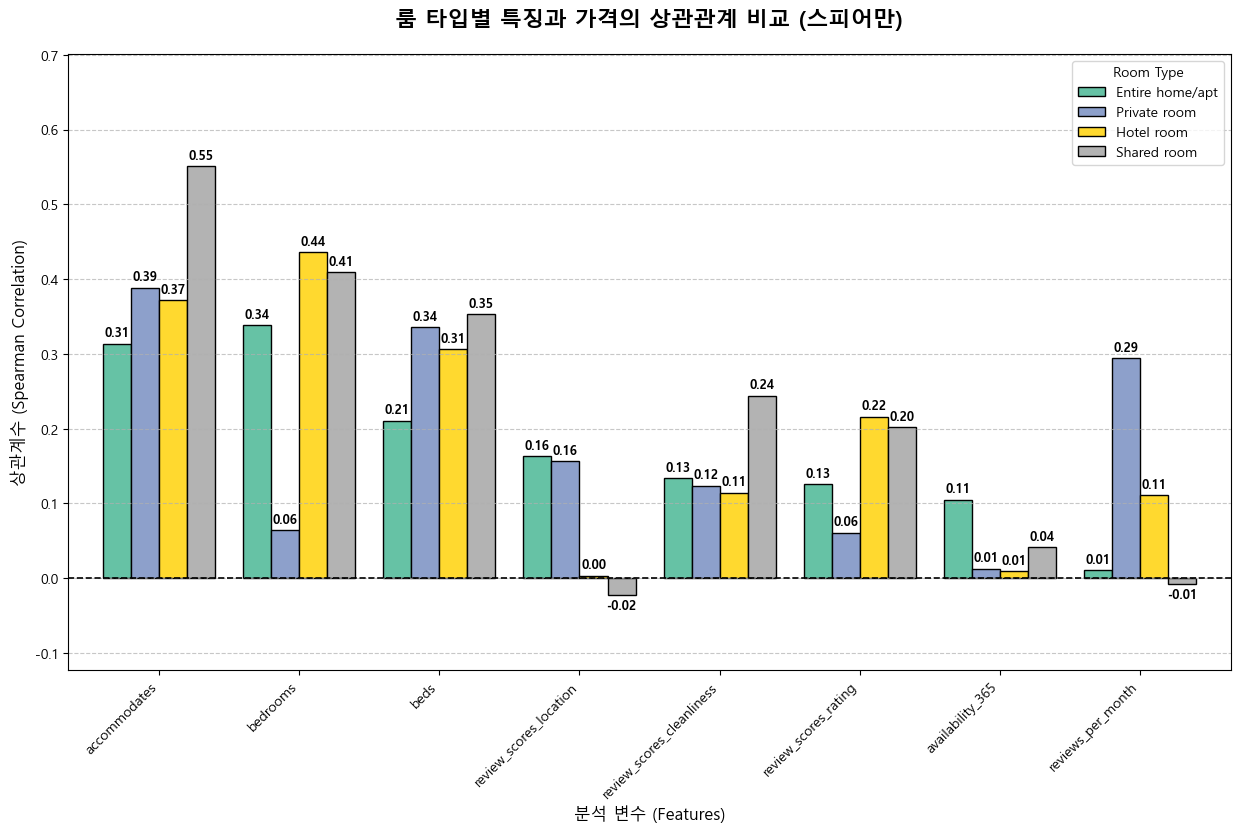

In [109]:
# (1~4단계 데이터 전처리 부분은 아까와 동일하게 유지합니다)
target_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 
    'review_scores_location', 'review_scores_cleanliness', 
    'review_scores_rating', 'availability_365', 'reviews_per_month'
]

private_df = df_cleaned[df_cleaned['room_type'] == 'Private room'][target_cols]
entire_df = df_cleaned[df_cleaned['room_type'] == 'Entire home/apt'][target_cols]
hotel_df = df_cleaned[df_cleaned['room_type'] == 'Hotel room'][target_cols]
shared_df = df_cleaned[df_cleaned['room_type'] == 'Shared room'][target_cols]

private_corr = private_df.corr(method='spearman')['price'].rename('Private room')
entire_corr = entire_df.corr(method='spearman')['price'].rename('Entire home/apt')
hotel_corr = hotel_df.corr(method='spearman')['price'].rename('Hotel room')
shared_corr = shared_df.corr(method='spearman')['price'].rename('Shared room')

comparison_df = pd.concat([entire_corr, private_corr, hotel_corr, shared_corr], axis=1).drop('price')

# ==========================================
# 5. 막대 차트 시각화 (숫자 표시 기능 추가!)
# ==========================================
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# ax 변수에 그래프를 담아줍니다.
ax = comparison_df.plot(kind='bar', figsize=(15, 8), width=0.8, colormap='Set2', edgecolor='black')

# 💡 핵심 추가: 막대마다 끝에 상관계수 값 표시하기
for container in ax.containers:
    ax.bar_label(container, 
                 fmt='%.2f',      # 소수점 둘째 자리까지 표시
                 padding=3,       # 막대 끝과 숫자 사이의 간격
                 fontsize=9,      # 숫자 크기 (너무 크면 겹치므로 약간 작게)
                 fontweight='bold')

# 그래프 디테일 꾸미기
plt.title('룸 타입별 특징과 가격의 상관관계 비교 (스피어만)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('분석 변수 (Features)', fontsize=12)
plt.ylabel('상관계수 (Spearman Correlation)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 숫자가 적히면서 그래프 천장을 뚫고 나갈 수 있으므로, y축 여백을 살짝 늘려줍니다.
plt.ylim(comparison_df.min().min() - 0.1, comparison_df.max().max() + 0.15)

plt.legend(title='Room Type', fontsize='10', loc='upper right')

plt.show()

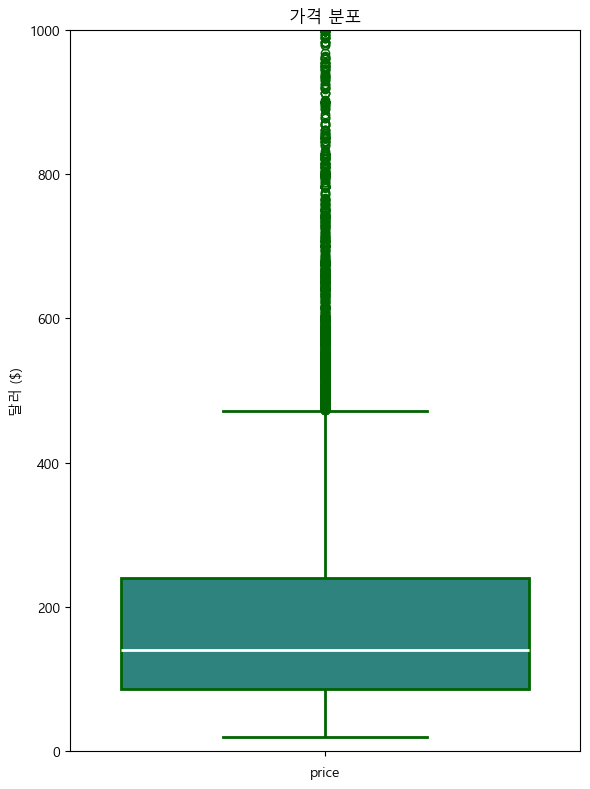

In [110]:
data_price = df[['price']]
plt.figure(figsize=(6, 8))
sns.boxplot(data=data_price, y='price', palette='viridis', linecolor='darkgreen', linewidth=2, medianprops={'color': 'white'})
sns.set_style("whitegrid")
plt.title("가격 분포")
plt.xlabel("price")
plt.ylabel("달러 ($)")
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

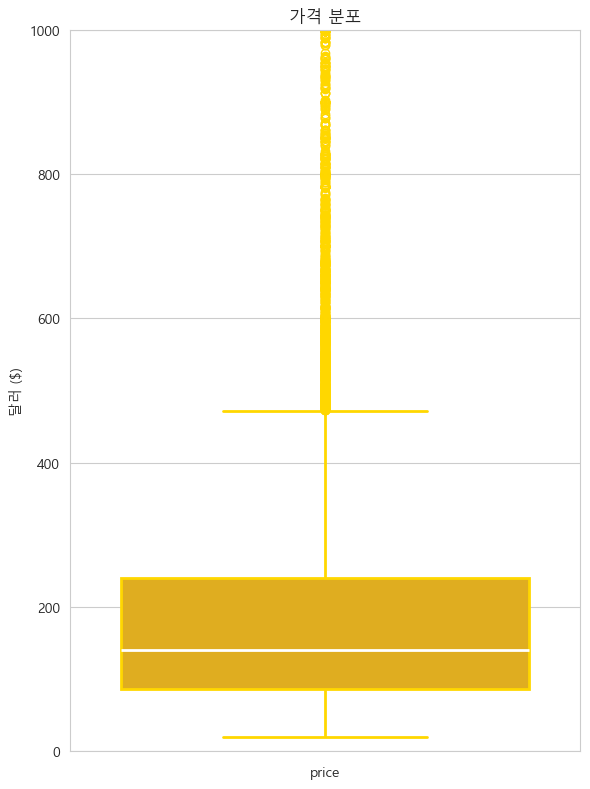

In [111]:
data_price = df_cleaned[['price']]
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(6, 8))
sns.boxplot(data=data_price, y='price', palette='Wistia', linecolor='gold', linewidth=2, medianprops={'color': 'white'})
sns.set_style("whitegrid")
plt.title("가격 분포")
plt.xlabel("price")
plt.ylabel("달러 ($)")
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

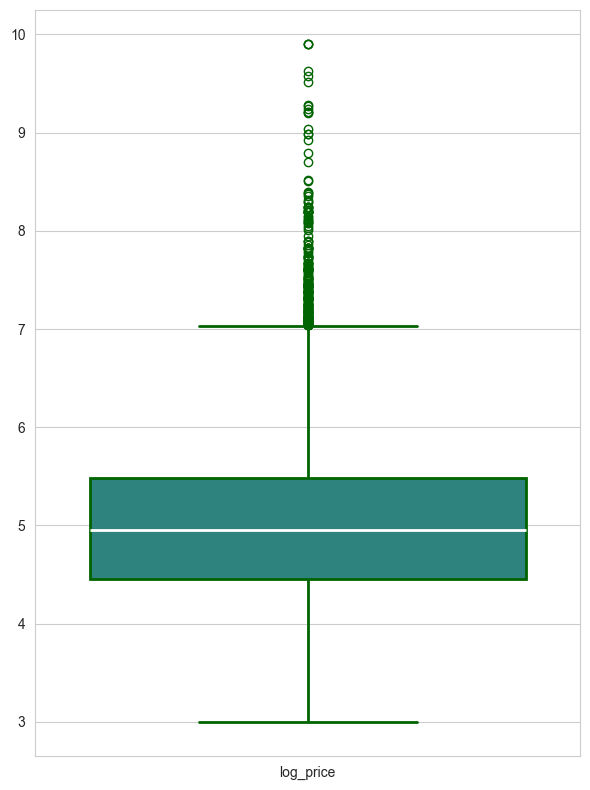

In [112]:
data_price = df_cleaned[['log_price']]
plt.figure(figsize=(6, 8))
sns.boxplot(data=data_price, palette='viridis', linecolor='darkgreen', linewidth=2, medianprops={'color': 'white'})
sns.set_style("whitegrid")
# plt.title("가격 분포")
# plt.xlabel("price")
# plt.ylabel("달러 ($)")
plt.tight_layout()
plt.show()

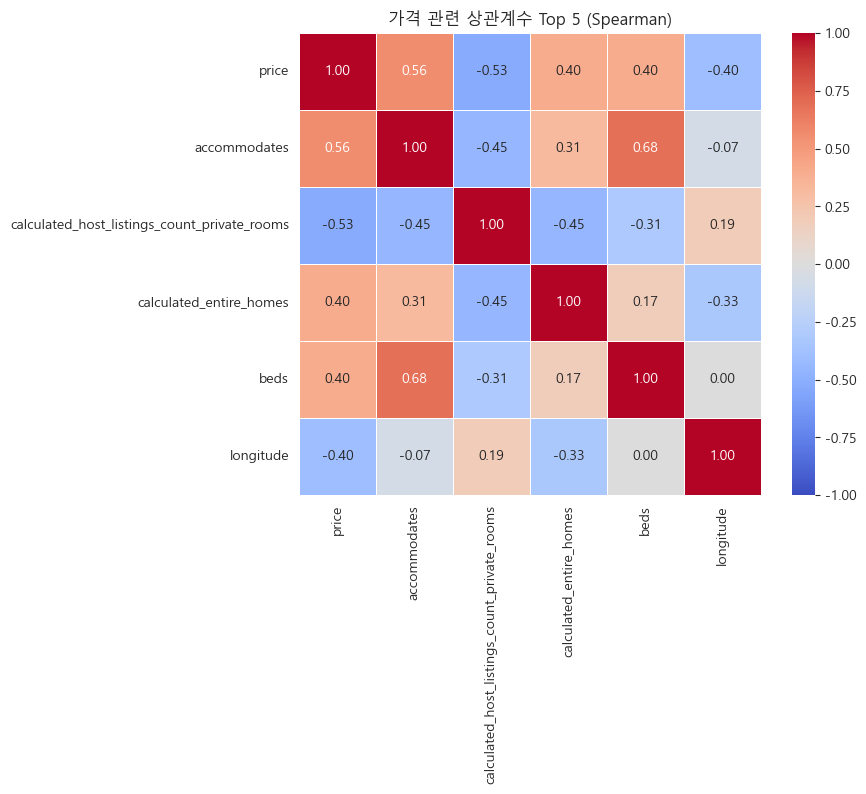

=== 🎯 'price' 기준 Top 5 변수 통계 검정 결과 ===
📌 변수명: accommodates
 - 상관계수: 0.5575
 - p-value : 0.00000
 👉 결론: 통계적으로 매우 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: calculated_host_listings_count_private_rooms
 - 상관계수: -0.5263
 - p-value : 0.00000
 👉 결론: 통계적으로 매우 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: calculated_entire_homes
 - 상관계수: 0.4037
 - p-value : 0.00000
 👉 결론: 통계적으로 매우 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: beds
 - 상관계수: 0.4021
 - p-value : 0.00000
 👉 결론: 통계적으로 매우 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: longitude
 - 상관계수: -0.4001
 - p-value : 0.00000
 👉 결론: 통계적으로 매우 유의미한 상관관계가 있습니다! (p < 0.05)



In [113]:
# 가격 기준 상관계수 구할 컬럼 선정
target_columns = list(df_cleaned.columns)

# 수치형 데이터만 추출
numeric_df = df_cleaned[target_columns].select_dtypes(include=['number'])

# 💡 핵심 추가: 상관계수를 구하기 전에 'log_price' 컬럼을 데이터프레임에서 제외합니다.
# (에러 방지를 위해 errors='ignore'를 추가하면 혹시 컬럼이 없어도 코드가 멈추지 않습니다.)
numeric_df = numeric_df.drop(columns=['log_price'], errors='ignore')
numeric_df.rename(columns={'calculated_host_listings_count_entire_homes': 'calculated_entire_homes'}, inplace=True)

# 수치형 데이터에서 상관계수 행렬 구하기
numeric_corr_matrix = numeric_df.corr(method = 'spearman')

# 'price'와 상관계수가 높은 상위 5개 변수 추출 (price 자기 자신을 포함하여 6개 선택)  /  절대값 추가를 위해 .abs() 추가
top_cols = numeric_corr_matrix.abs().nlargest(6, 'price').index

# 추출한 컬럼들로만 구성된 새로운 상관계수 데이터프레임 만들기
top_corr = numeric_df[top_cols].corr(method = 'spearman')

# 글씨 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 히트맵 그리기
plt.figure(figsize=(8, 6)) # 그래프 크기 조절
sns.heatmap(top_corr, 
            annot=True,        # 셀 안에 상관계수 숫자 표시
            fmt='.2f',         # 숫자를 소수점 둘째 자리까지만 표시
            cmap='coolwarm',   # 색상 테마 (추천: coolwarm, RdYlBu_r, Blues)
            vmin=-1, vmax=1,   # 상관계수 최소/최대 범위 고정 (-1 ~ 1)
            linewidths=.5,     # 셀 사이 구분선 굵기
            square=True)       # 각 셀을 정사각형 모양으로 만들기

# 그래프 제목 설정
plt.title('가격 관련 상관계수 Top 5 (Spearman)')
plt.show()

#--------------------------------------------------------------------------------------------------

import scipy.stats as stats

print("=== 🎯 'price' 기준 Top 5 변수 통계 검정 결과 ===")

# top_cols에는 'price'를 포함해 6개의 변수가 들어있습니다.
for col in top_cols:
    # 자기 자신('price')과의 검정은 의미가 없으므로 건너뜁니다.
    if col == 'price':
        continue
    
    # 두 변수 중 하나라도 결측치(NaN)가 있으면 에러가 날 수 있으므로 결측치 제거
    valid_data = numeric_df[['price', col]].dropna()
    
    # 1. 스피어만(Spearman) 상관계수와 p-value 검정 (히트맵과 동일한 기준)
    coef, p_value = stats.spearmanr(valid_data['price'], valid_data[col])
    
    # 2. 만약 스피어만(Spearman)으로 검정하고 싶다면 위 줄을 지우고 아래 줄을 사용하세요!
    # coef, p_value = stats.spearmanr(valid_data['price'], valid_data[col])
    
    print(f"📌 변수명: {col}")
    print(f" - 상관계수: {coef:.4f}")
    print(f" - p-value : {p_value:.5f}")
    
    # p-value가 0.05(5%) 미만인지 확인하여 결론 출력
    if p_value < 0.05:
        print(" 👉 결론: 통계적으로 매우 유의미한 상관관계가 있습니다! (p < 0.05)\n")
    else:
        print(" 👉 결론: 우연일 가능성이 높습니다. (통계적 유의성 없음)\n")

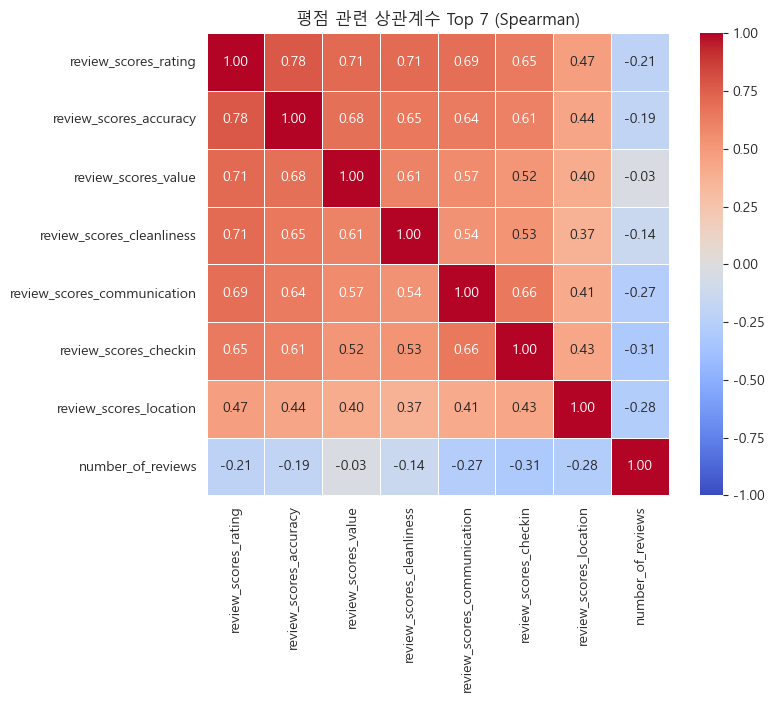

=== 🎯 'review_scores_rating' 기준 Top 변수 통계 검정 결과 (스피어만) ===
📌 변수명: review_scores_accuracy
 - 스피어만 상관계수: 0.7789
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: review_scores_value
 - 스피어만 상관계수: 0.7118
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: review_scores_cleanliness
 - 스피어만 상관계수: 0.7071
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: review_scores_communication
 - 스피어만 상관계수: 0.6915
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: review_scores_checkin
 - 스피어만 상관계수: 0.6472
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: review_scores_location
 - 스피어만 상관계수: 0.4737
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)

📌 변수명: number_of_reviews
 - 스피어만 상관계수: -0.2135
 - p-value : 0.00000
 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)



In [114]:
# 1. 25~50번째 컬럼 슬라이싱 + review_scores_rating 포함
target_columns_rv = list(df_cleaned.columns) 

# 2. 그 중 수치형 데이터만 추출
numeric_df_rv = df_cleaned[target_columns].select_dtypes(include=['number'])

# 3. 스피어만 상관계수 계산 (이상치에 강함)
review_scores_rating_corr = numeric_df_rv.corr(method = 'spearman')

# 'price'와 상관계수가 높은 상위 5개 변수 추출 (price 자기 자신을 포함하여 6개 선택)  /  절대값 추가를 위해 .abs() 추가
top_cols_rv = review_scores_rating_corr.abs().nlargest(8, 'review_scores_rating').index

# 추출한 컬럼들로만 구성된 새로운 상관계수 데이터프레임 만들기
top_corr_rv = numeric_df_rv[top_cols_rv].corr(method = 'spearman')

# 글씨 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 히트맵 그리기
plt.figure(figsize=(8, 6)) # 그래프 크기 조절
sns.heatmap(top_corr_rv, 
            annot=True,        # 셀 안에 상관계수 숫자 표시
            fmt='.2f',         # 숫자를 소수점 둘째 자리까지만 표시
            cmap='coolwarm',   # 색상 테마 (추천: coolwarm, RdYlBu_r, Blues)
            vmin=-1, vmax=1,   # 상관계수 최소/최대 범위 고정 (-1 ~ 1)
            linewidths=.5,     # 셀 사이 구분선 굵기
            square=True)       # 각 셀을 정사각형 모양으로 만들기

# 그래프 제목 설정
plt.title('평점 관련 상관계수 Top 7 (Spearman)')
plt.show()

#------------------------------------------------------------------------------------------------------
import scipy.stats as stats

print("=== 🎯 'review_scores_rating' 기준 Top 변수 통계 검정 결과 (스피어만) ===")

# top_cols_rv에는 'review_scores_rating'을 포함해 8개의 변수가 들어있습니다.
for col in top_cols_rv:
    # 자기 자신과의 검정은 의미가 없으므로 건너뜁니다.
    if col == 'review_scores_rating':
        continue
    
    # 두 변수 중 하나라도 결측치(NaN)가 있으면 에러가 날 수 있으므로 결측치 동시 제거
    valid_data = numeric_df_rv[['review_scores_rating', col]].dropna()
    
    # 스피어만(Spearman) 상관계수와 p-value 검정
    coef, p_value = stats.spearmanr(valid_data['review_scores_rating'], valid_data[col])
    
    print(f"📌 변수명: {col}")
    print(f" - 스피어만 상관계수: {coef:.4f}")
    print(f" - p-value : {p_value:.5f}")
    
    # p-value가 0.05(5%) 미만인지 확인하여 결론 출력
    if p_value < 0.05:
        print(" 👉 결론: 통계적으로 유의미한 상관관계가 있습니다! (p < 0.05)\n")
    else:
        print(" 👉 결론: 우연일 가능성이 높습니다. (통계적 유의성 없음)\n")